In [ ]:
import pandas as pd
df_bc = pd.read_csv("breast_cancer.csv")
df_heart = pd.read_csv("heart.csv")
url  = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df_diab = pd.read_csv(url, names=cols)

Heart Disease

In [ ]:
df_heart['target'] = df_heart['target'].astype(int).apply(lambda x: 1 if x > 0 else 0)

In [ ]:
print("=== HEART DISEASE DATASET ===")
print(df_heart.info())
print("\n", df_heart.describe())
print("\nClass balance:\n", df_heart['target'].value_counts())
print("\nMissing values:\n", df_heart.isnull().sum())

=== HEART DISEASE DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

                age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610  

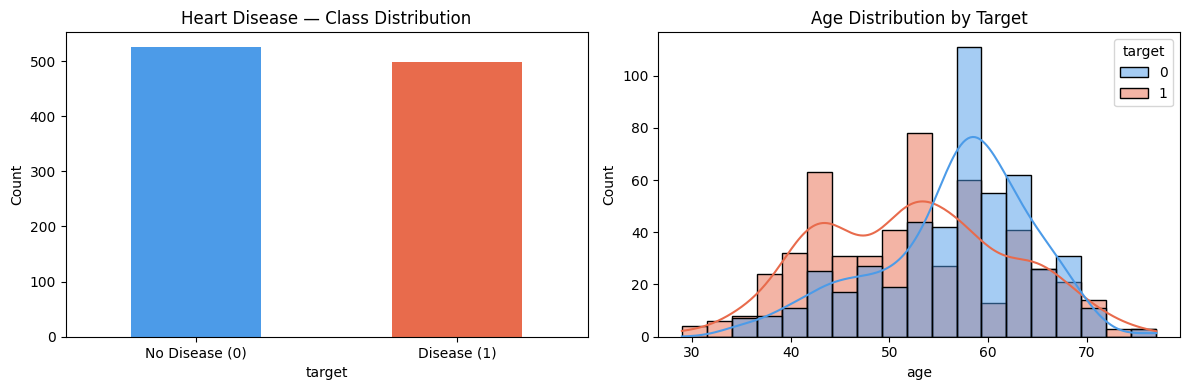

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_heart['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C9BE8','#E86B4C'])
axes[0].set_title('Heart Disease — Class Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')

sns.histplot(data=df_heart, x='age', hue='target', kde=True, ax=axes[1], palette=['#4C9BE8','#E86B4C'])
axes[1].set_title('Age Distribution by Target')
plt.tight_layout(); plt.show()

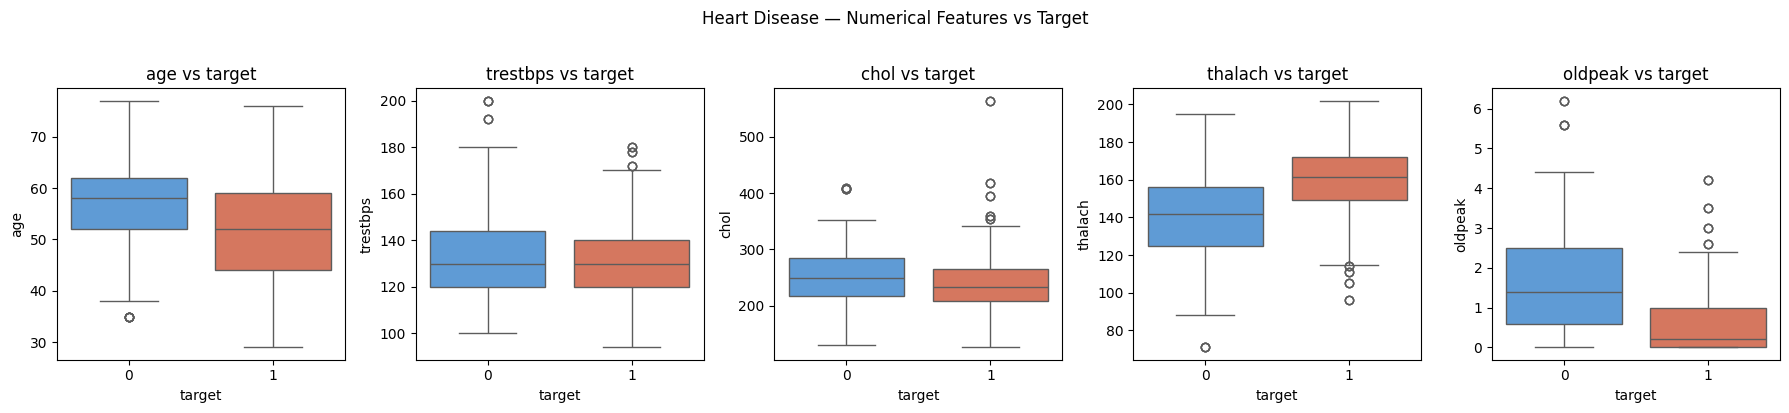

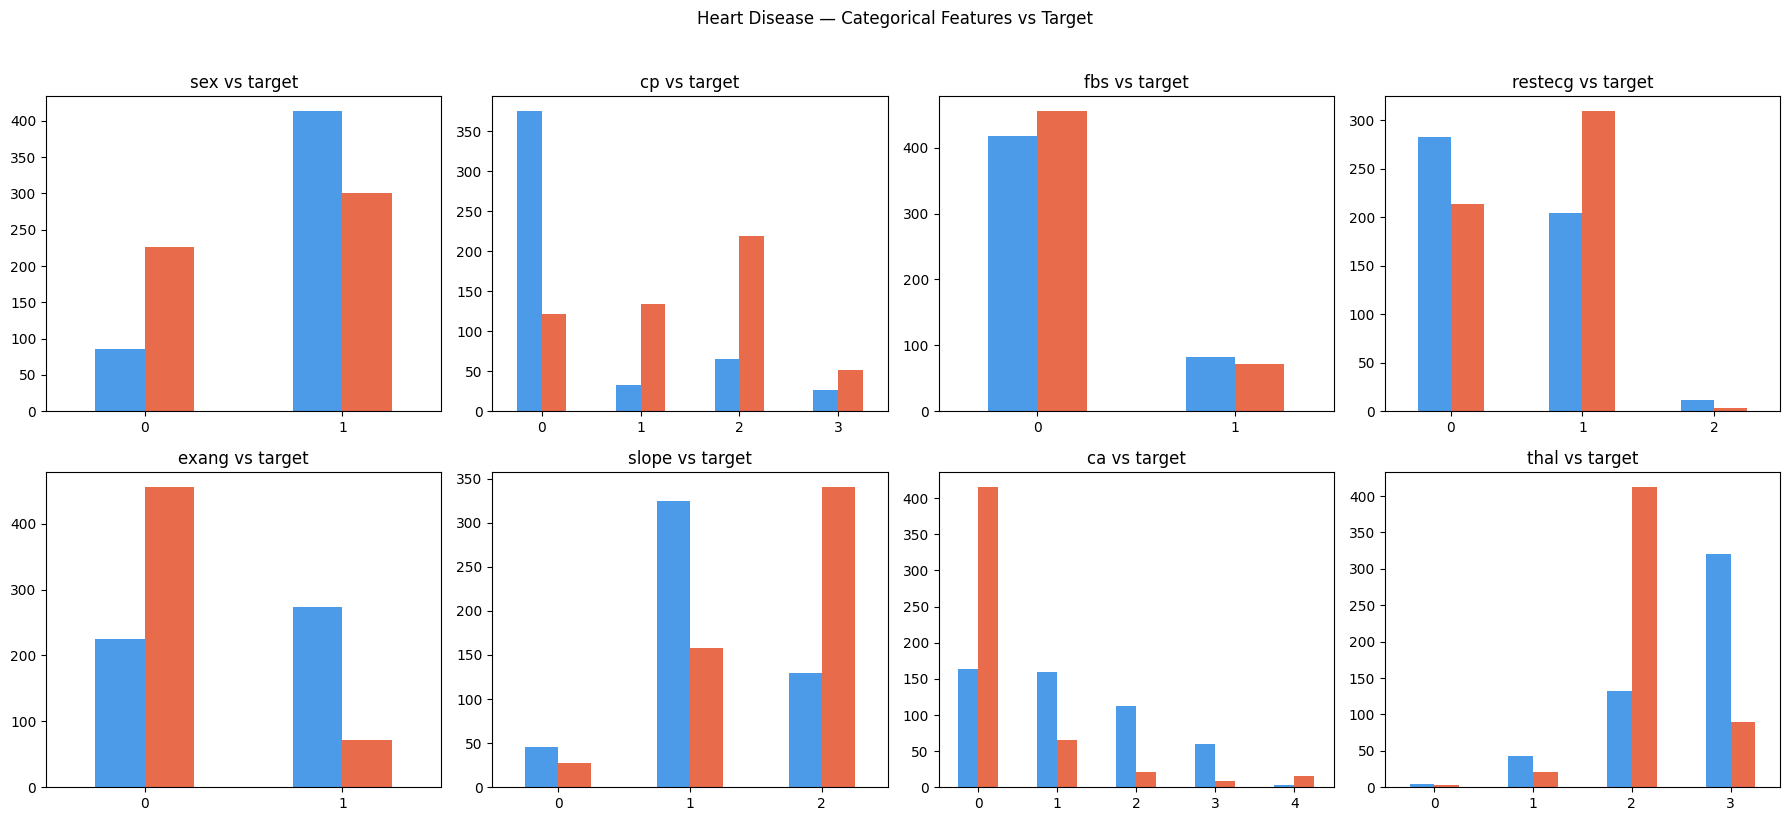

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Feature distributions ───────────────────────────────────────────────────
cat_cols  = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
num_cols  = ['age','trestbps','chol','thalach','oldpeak']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_heart, x='target', y=col, hue='target', ax=ax,
                palette=['#4C9BE8','#E86B4C'], legend=False)
    ax.set_title(f'{col} vs target')
plt.suptitle('Heart Disease — Numerical Features vs Target', y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = df_heart.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#4C9BE8','#E86B4C'], legend=False)
    ax.set_title(f'{col} vs target'); ax.set_xlabel(''); ax.tick_params(rotation=0)
plt.suptitle('Heart Disease — Categorical Features vs Target', y=1.02)
plt.tight_layout(); plt.show()

Diabetes

In [ ]:
# ── Basic info ──────────────────────────────────────────────────────────────
print("=== DIABETES DATASET ===")
print(df_diab.info())
print("\n", df_diab.describe())
print("\nClass balance:\n", df_diab['Outcome'].value_counts())



=== DIABETES DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.53

In [ ]:
# ── Zero-value audit (zeros = likely missing in medical features) ────────────
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("\nZero counts (= missing data):")
print((df_diab[zero_cols] == 0).sum())



Zero counts (= missing data):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


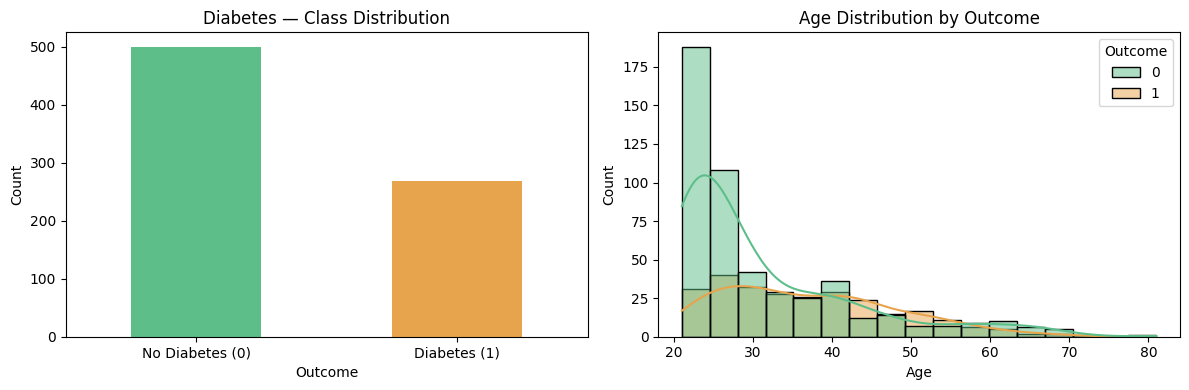

In [ ]:
# ── Class distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_diab['Outcome'].value_counts().plot(kind='bar', ax=axes[0],
                                        color=['#5DBE8A','#E8A44C'])
axes[0].set_title('Diabetes — Class Distribution')
axes[0].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
axes[0].set_ylabel('Count')

sns.histplot(data=df_diab, x='Age', hue='Outcome', kde=True,
             ax=axes[1], palette=['#5DBE8A','#E8A44C'])
axes[1].set_title('Age Distribution by Outcome')
plt.tight_layout(); plt.show()

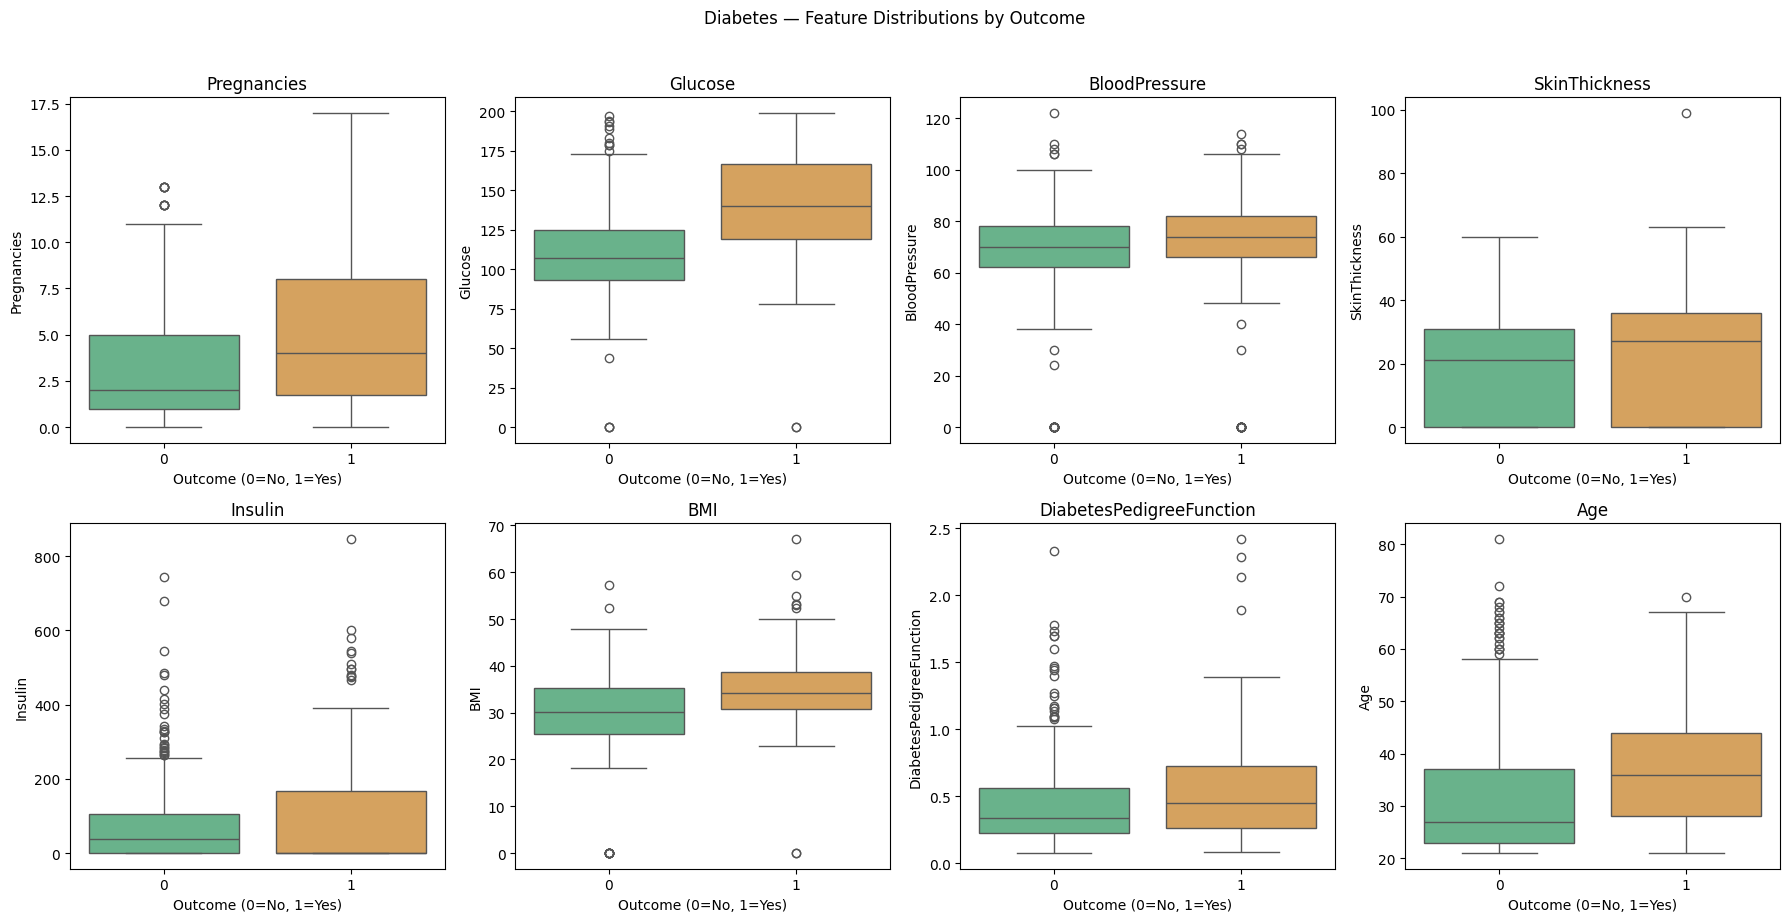

In [ ]:
# ── Boxplots — all 8 features vs target ────────────────────────────────────
feature_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                'Insulin','BMI','DiabetesPedigreeFunction','Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df_diab, x='Outcome', y=col, hue='Outcome', ax=ax,
                palette=['#5DBE8A','#E8A44C'], legend=False)
    ax.set_title(f'{col}')
    ax.set_xlabel('Outcome (0=No, 1=Yes)')
plt.suptitle('Diabetes — Feature Distributions by Outcome', y=1.02)
plt.tight_layout(); plt.show()

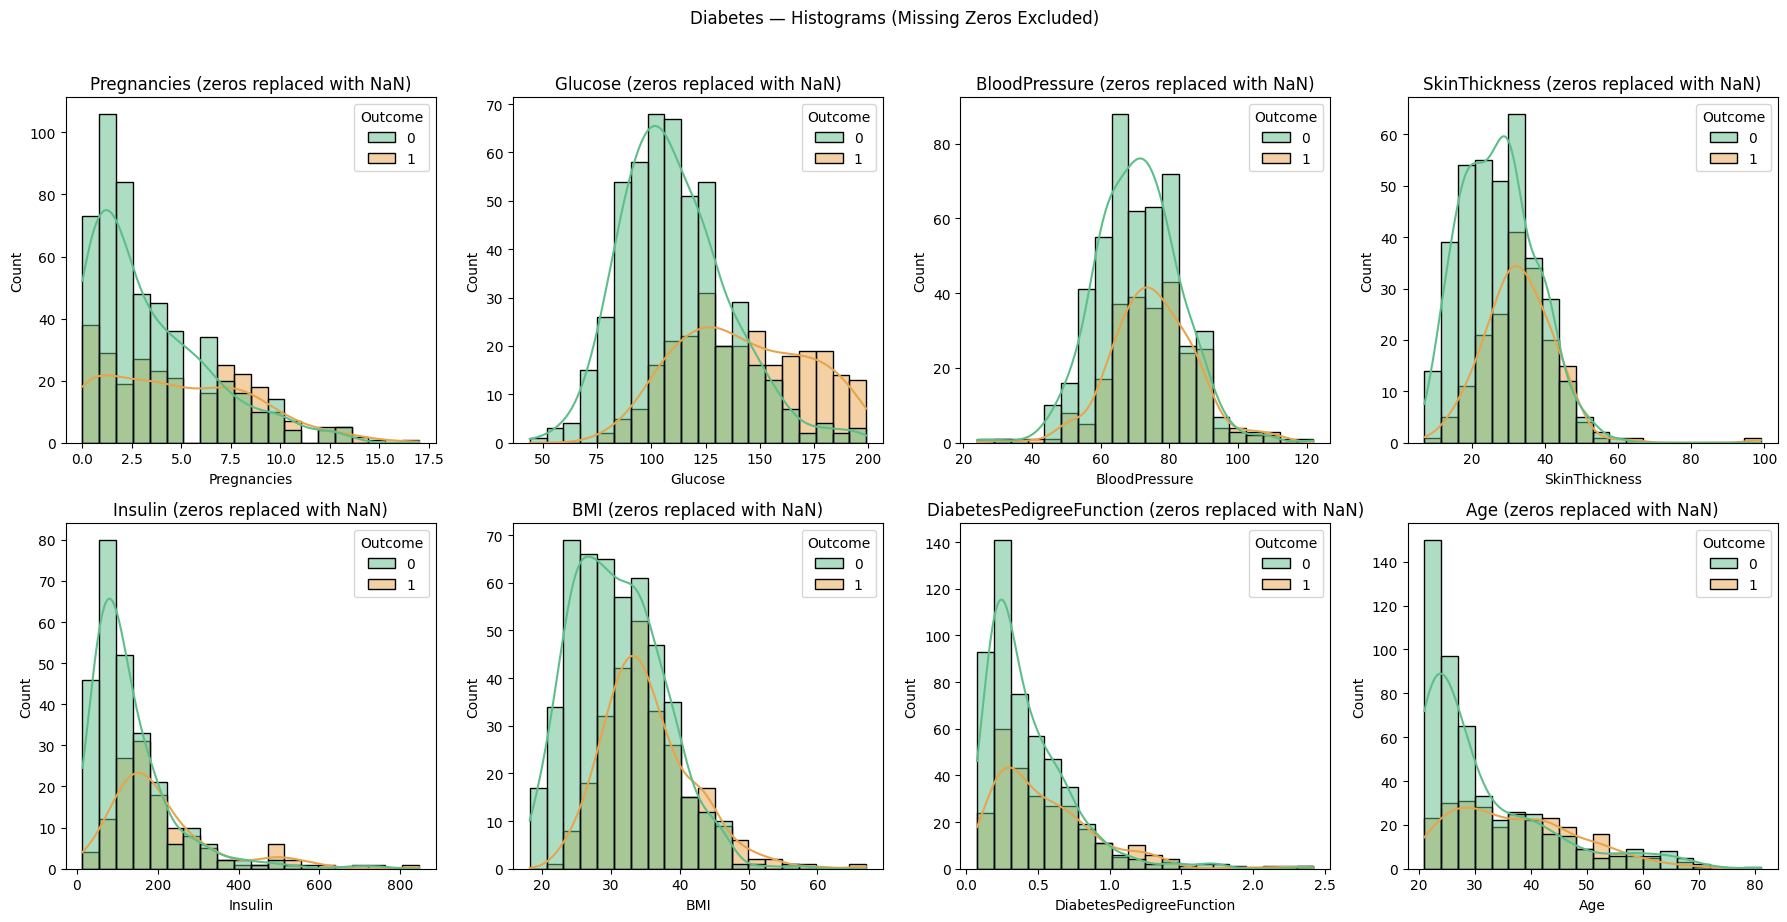

In [ ]:
# ── Distribution with zero-masking (show true distribution) ─────────────────
df_diab_masked = df_diab.copy()
df_diab_masked[zero_cols] = df_diab_masked[zero_cols].replace(0, np.nan)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.histplot(data=df_diab_masked, x=col, hue='Outcome', kde=True,
                 ax=ax, palette=['#5DBE8A','#E8A44C'], bins=20)
    ax.set_title(f'{col} (zeros replaced with NaN)')
plt.suptitle('Diabetes — Histograms (Missing Zeros Excluded)', y=1.02)
plt.tight_layout(); plt.show()

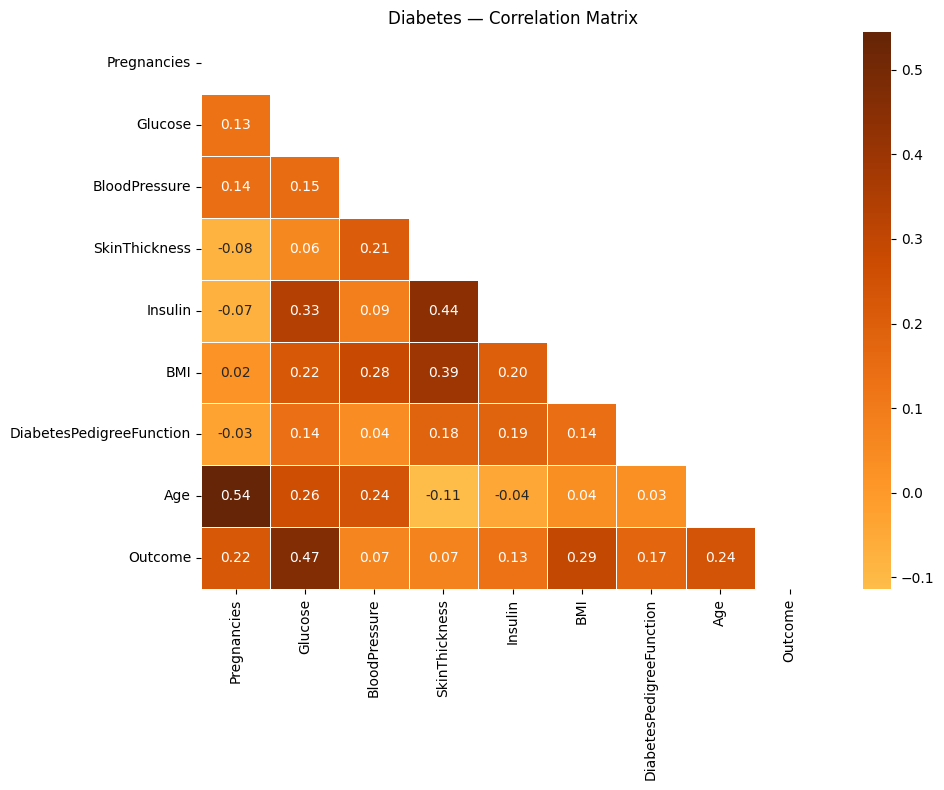

In [ ]:
# ── Correlation heatmap ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
corr = df_diab.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask,
            cmap='YlOrBr', center=0, linewidths=0.5)
plt.title('Diabetes — Correlation Matrix')
plt.tight_layout(); plt.show()

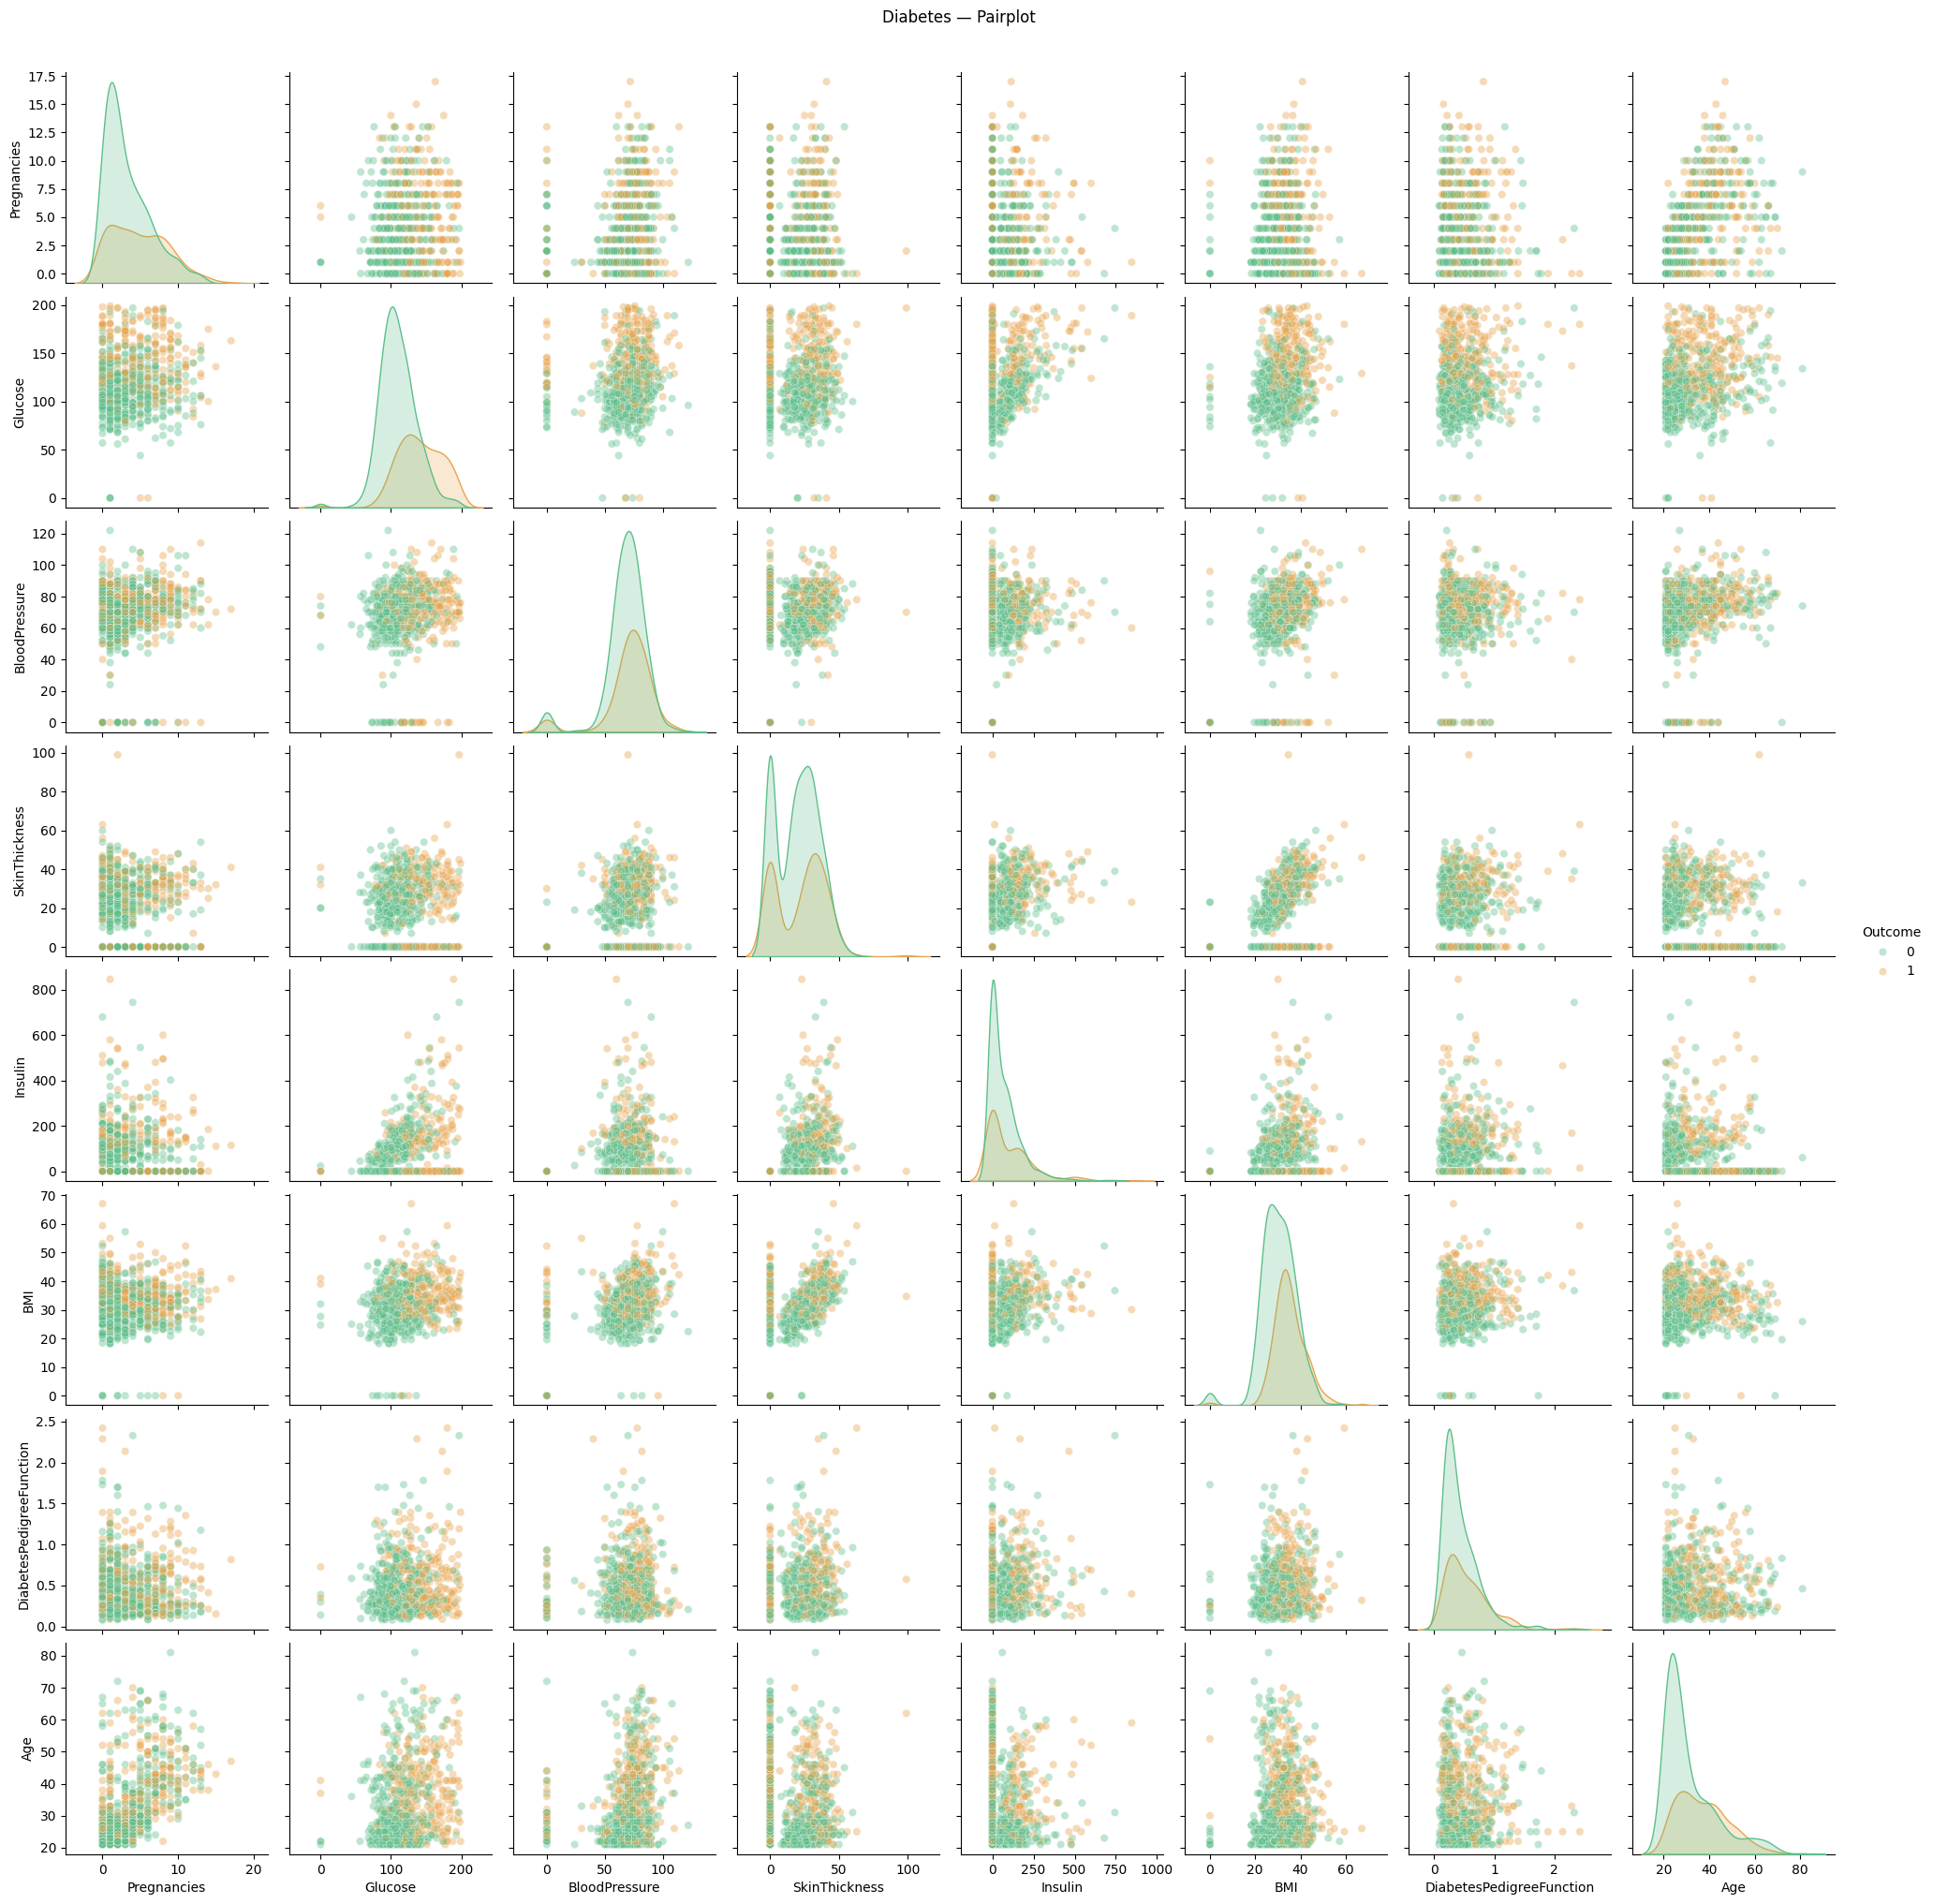

In [ ]:
# ── Pairplot ────────────────────────────────────────────────────────────────
sns.pairplot(df_diab, hue='Outcome', palette=['#5DBE8A','#E8A44C'],
             plot_kws={'alpha': 0.4}, diag_kind='kde')
plt.suptitle('Diabetes — Pairplot', y=1.02); plt.show()

 Breast Cancer

In [ ]:
df_bc['target_name'] = df_bc['diagnosis'].map({'M': 'malignant', 'B': 'benign'})

In [ ]:
print("=== BREAST CANCER DATASET ===")
print(df_bc.info())
print("\n", df_bc.describe())
print("\nClass balance:\n", df_bc['diagnosis'].value_counts())
print("\nMissing values:\n", df_bc.isnull().sum().sum(), "total missing")

=== BREAST CANCER DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 

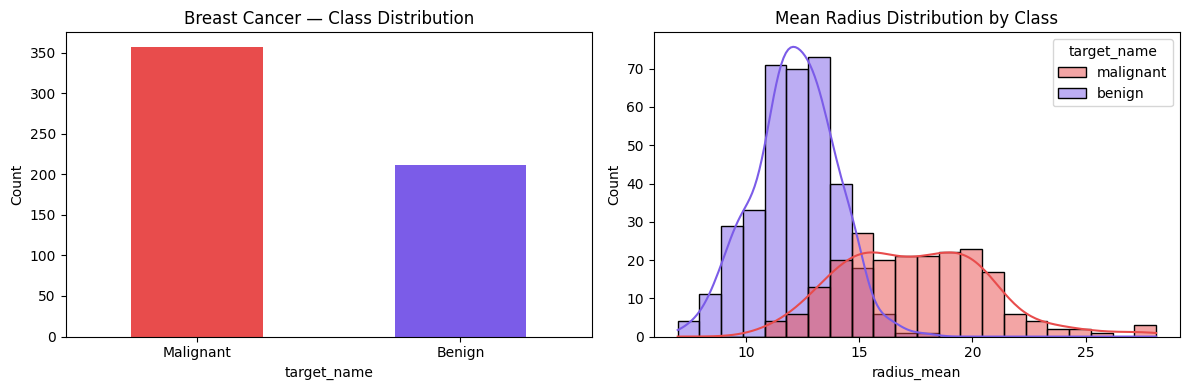

In [ ]:
# ── Class distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_bc['target_name'].value_counts().plot(kind='bar', ax=axes[0],
                                          color=['#E84C4C','#7B5CE8'])
axes[0].set_title('Breast Cancer — Class Distribution')
axes[0].set_xticklabels(['Malignant', 'Benign'], rotation=0)
axes[0].set_ylabel('Count')

# Mean radius by class
sns.histplot(data=df_bc, x='radius_mean', hue='target_name', kde=True,
             ax=axes[1], palette=['#E84C4C','#7B5CE8'])
axes[1].set_title('Mean Radius Distribution by Class')
plt.tight_layout(); plt.show()

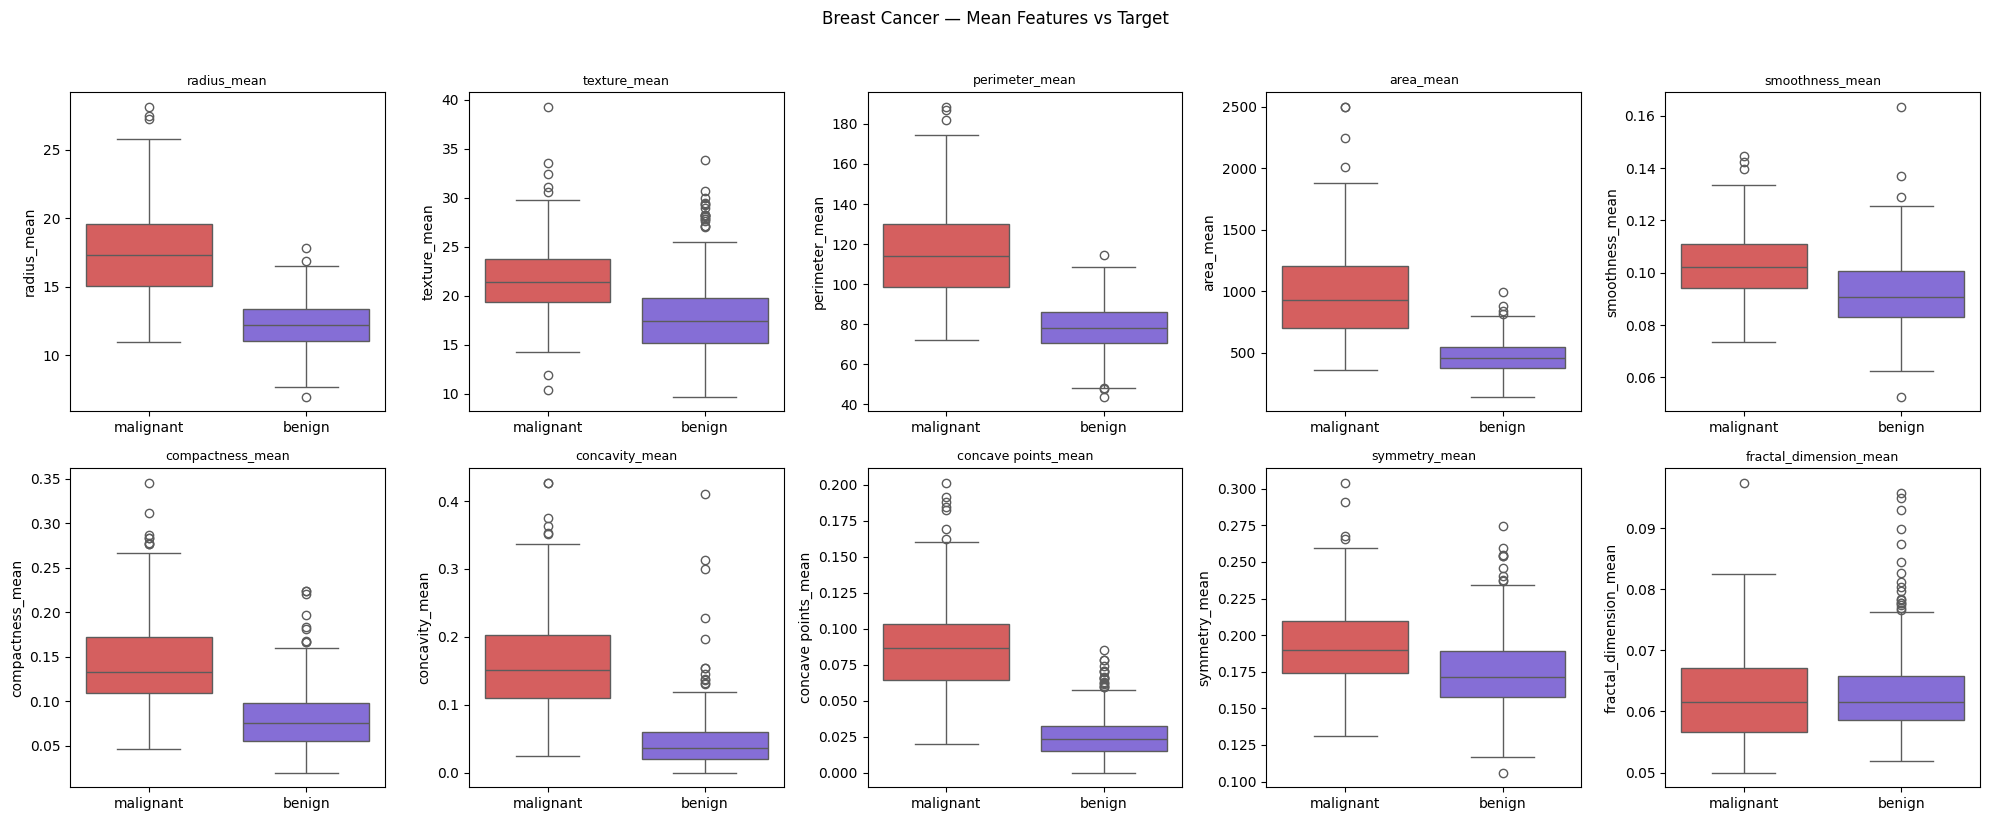

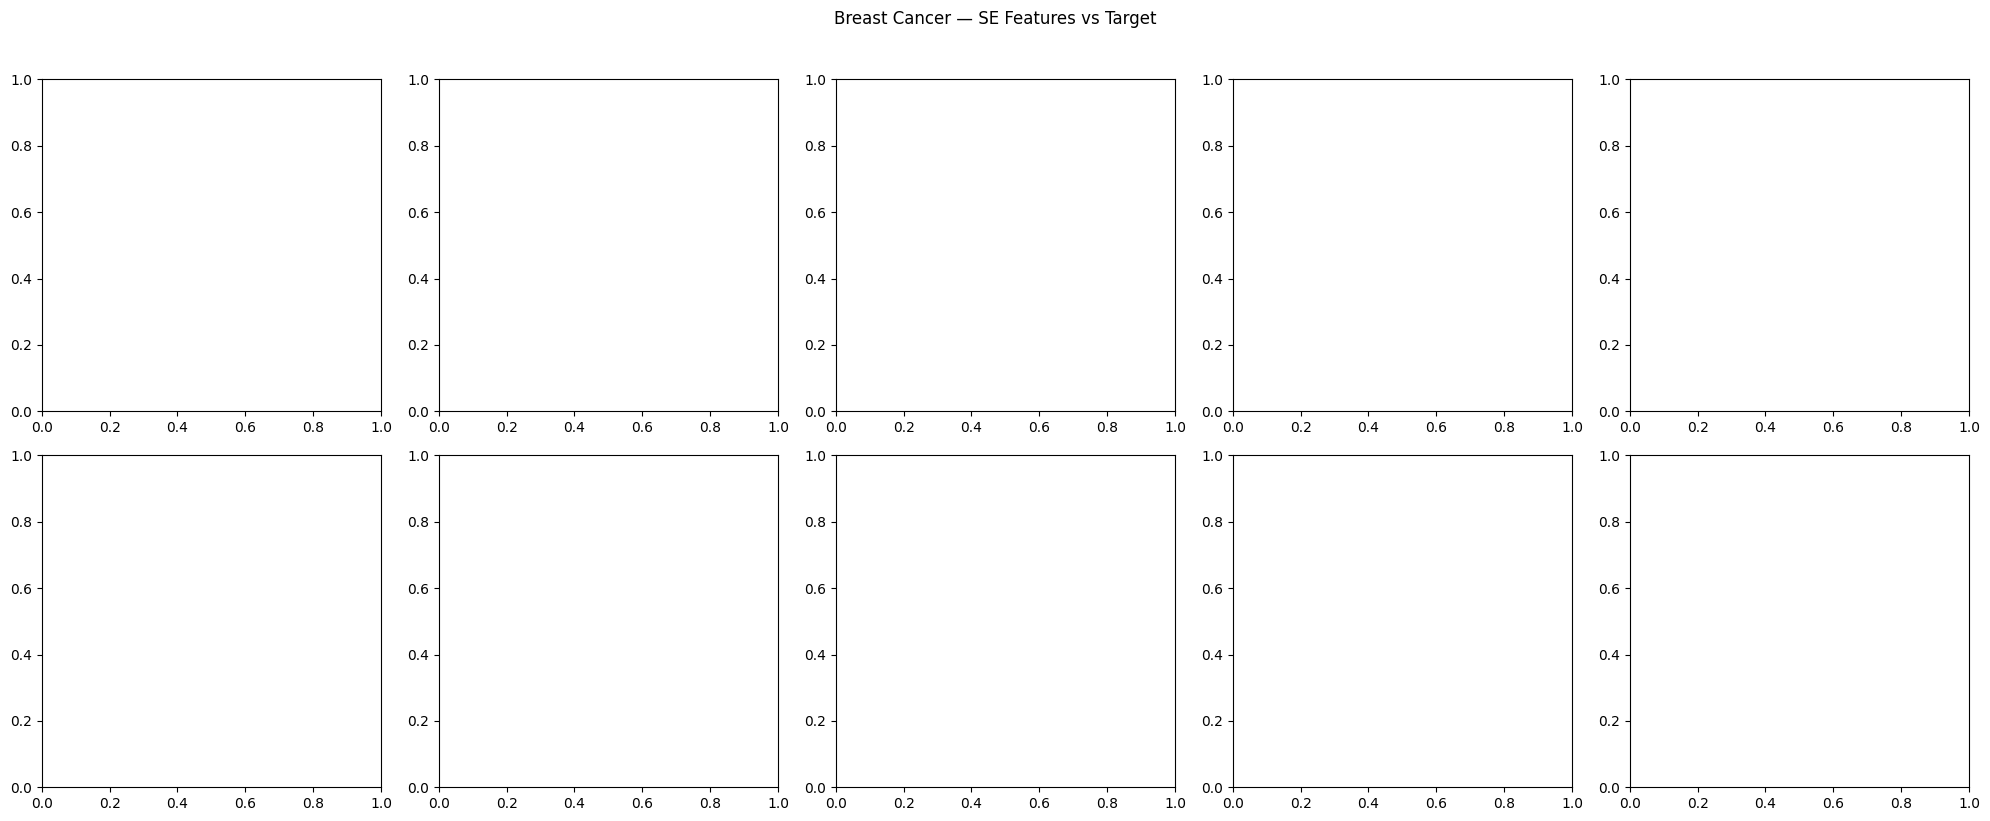

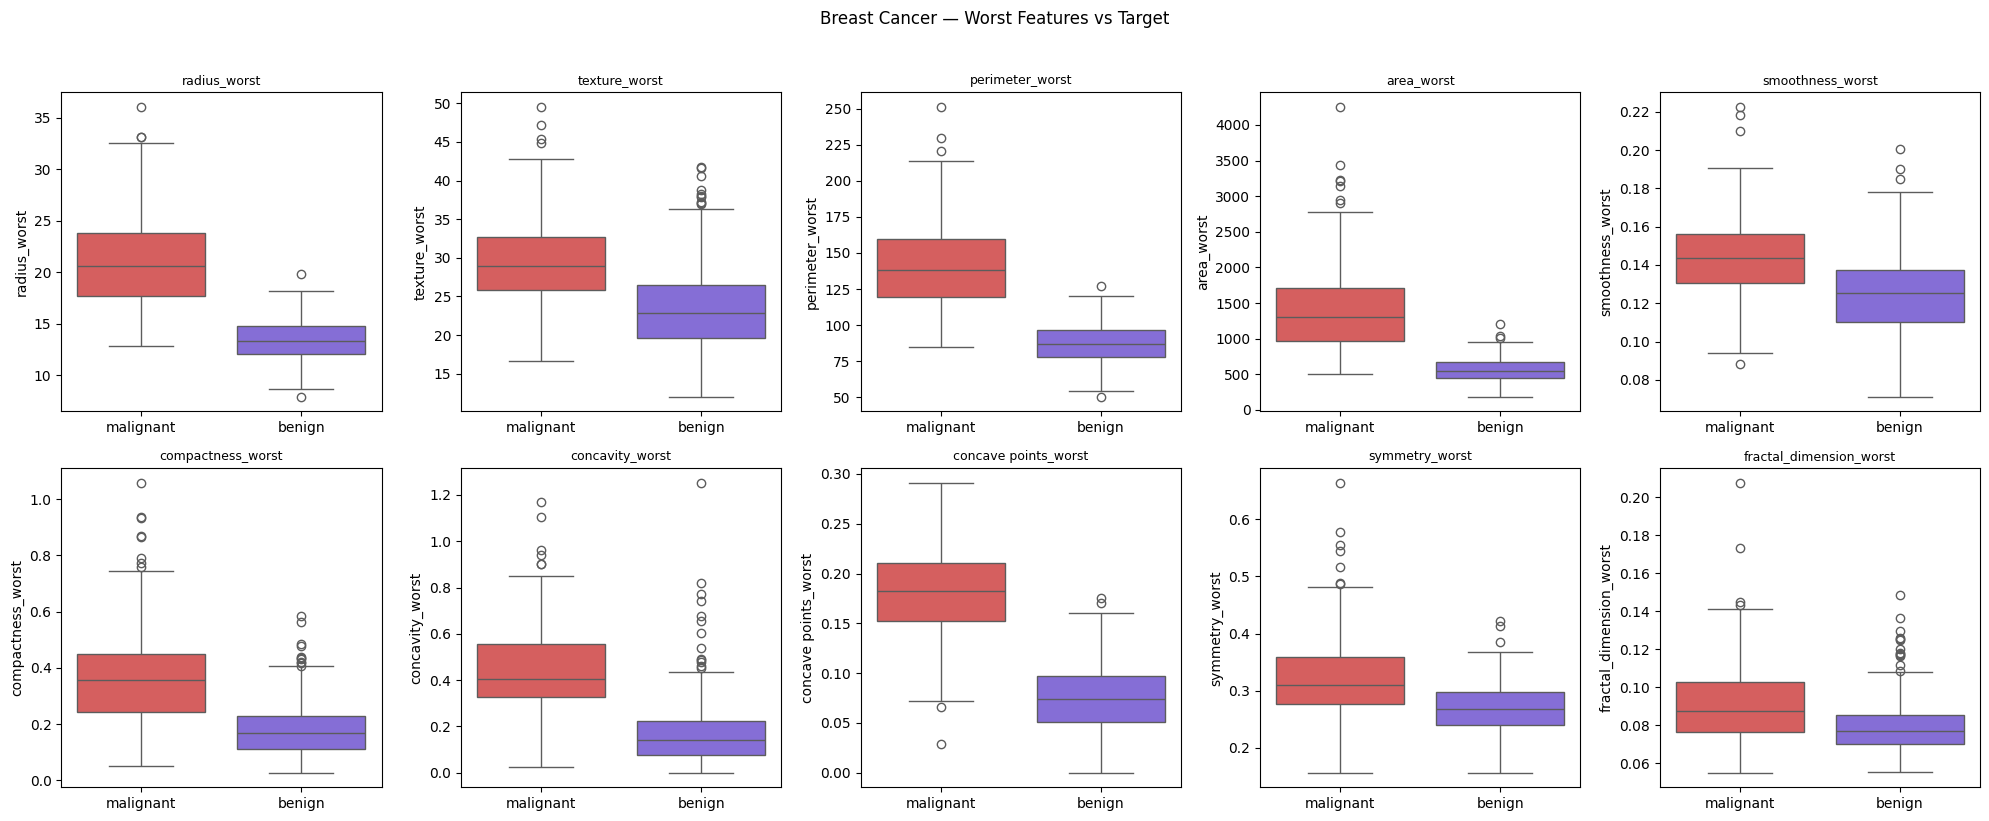

In [ ]:
# ── Feature group analysis (sklearn gives 3 groups: mean, SE, worst) ────────
mean_cols  = [c for c in df_bc.columns if 'mean'  in c and c != 'target_name']
se_cols    = [c for c in df_bc.columns if 'error' in c]
worst_cols = [c for c in df_bc.columns if 'worst' in c]

for group, cols in [("Mean Features", mean_cols),
                     ("SE Features",   se_cols),
                     ("Worst Features", worst_cols)]:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, col in zip(axes.flatten(), cols):
        sns.boxplot(data=df_bc, x='target_name', y=col, hue='target_name', ax=ax,
                    palette=['#E84C4C','#7B5CE8'], legend=False)
        ax.set_title(col.replace('mean ','').replace(' error','').replace('worst ',''),
                     fontsize=9)
        ax.set_xlabel('')
    plt.suptitle(f'Breast Cancer — {group} vs Target', y=1.02)
    plt.tight_layout(); plt.show()

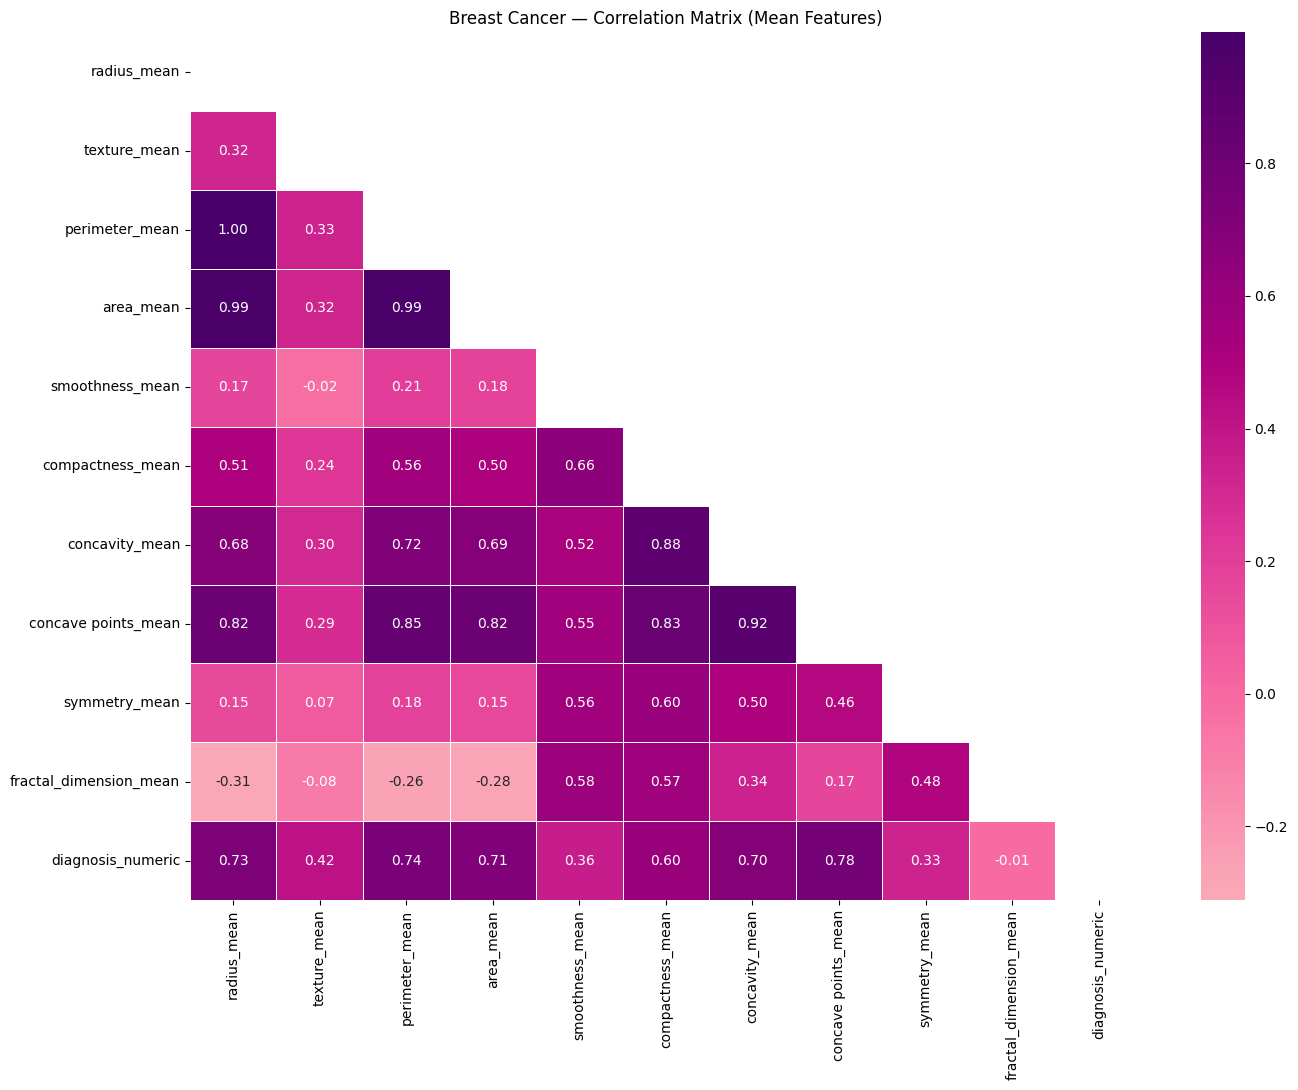

In [ ]:
# ── Correlation heatmap — mean features only (30 features is too dense) ─────
plt.figure(figsize=(14, 11))
# Convert 'diagnosis' column to numerical for correlation calculation
df_bc_corr = df_bc.copy()
df_bc_corr['diagnosis_numeric'] = df_bc_corr['diagnosis'].map({'B': 0, 'M': 1})
corr = df_bc_corr[mean_cols + ['diagnosis_numeric']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask,
            cmap='RdPu', center=0, linewidths=0.5)
plt.title('Breast Cancer — Correlation Matrix (Mean Features)')
plt.tight_layout(); plt.show()

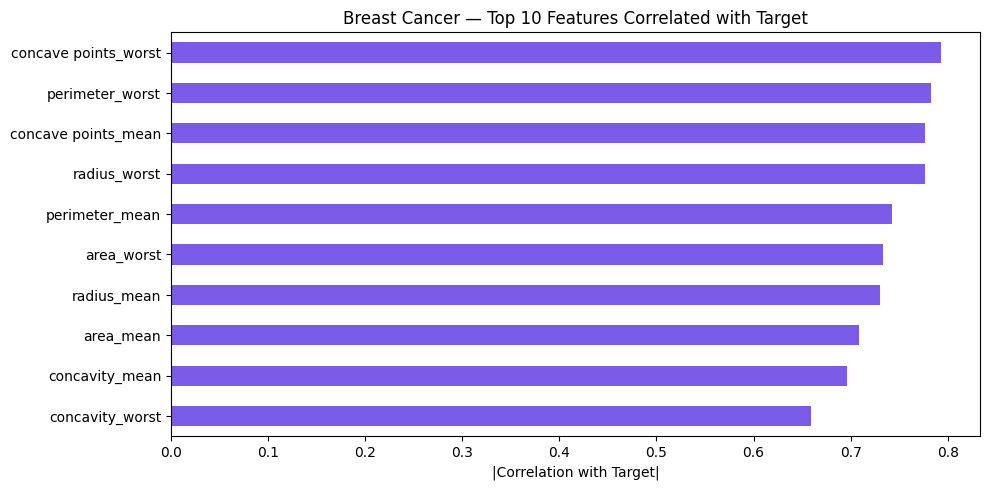

In [ ]:
# ── Top 10 features most correlated with target ──────────────────────────────
df_bc_numeric = df_bc.copy()
df_bc_numeric['diagnosis_numeric'] = df_bc_numeric['diagnosis'].map({'B': 0, 'M': 1})

top10 = (df_bc_numeric.drop(columns=['target_name', 'diagnosis'])
               .corr()['diagnosis_numeric']
               .drop('diagnosis_numeric')
               .abs()
               .sort_values(ascending=False)
               .head(10))

plt.figure(figsize=(10, 5))
top10.plot(kind='barh', color='#7B5CE8')
plt.title('Breast Cancer — Top 10 Features Correlated with Target')
plt.xlabel('|Correlation with Target|')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

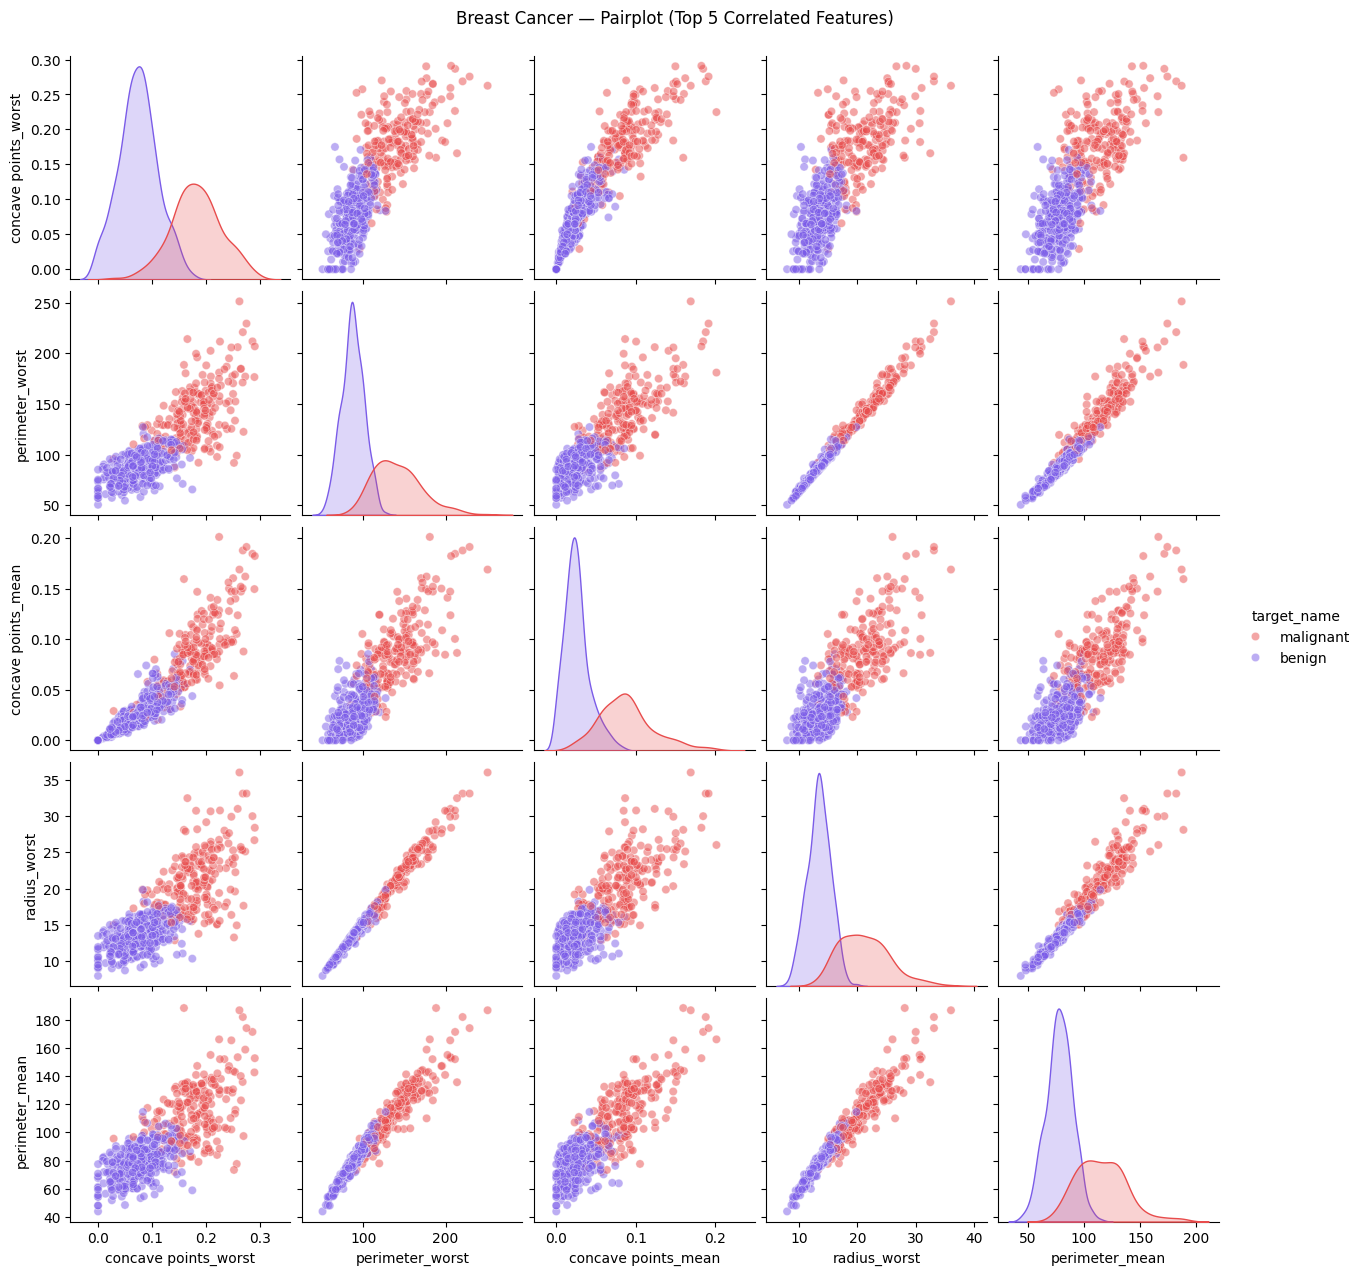

In [ ]:
# ── Pairplot — top 5 features only (30-feature pairplot is impractical) ─────
top5 = top10.index[:5].tolist()
sns.pairplot(df_bc[top5 + ['target_name']], hue='target_name',
             palette=['#E84C4C','#7B5CE8'],
             plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle('Breast Cancer — Pairplot (Top 5 Correlated Features)', y=1.02)
plt.show()


  HEART DISEASE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   1

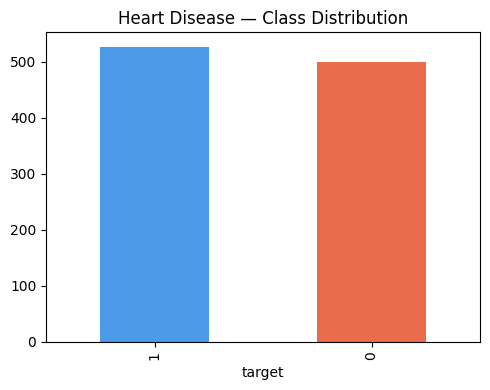

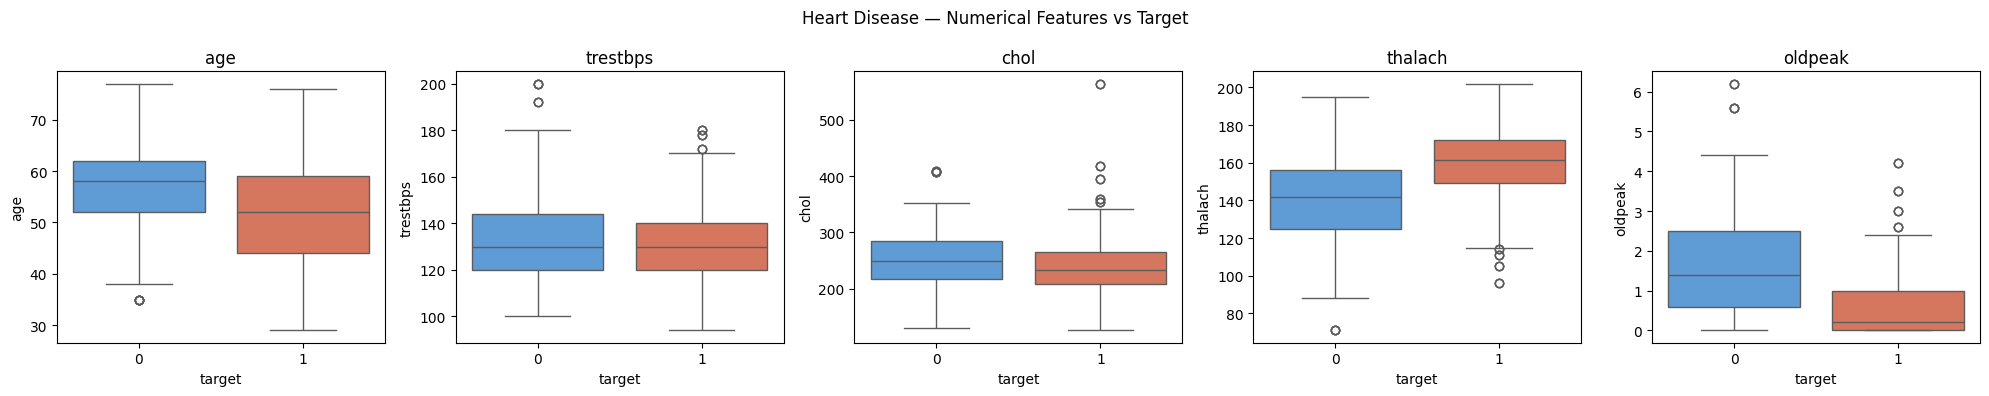

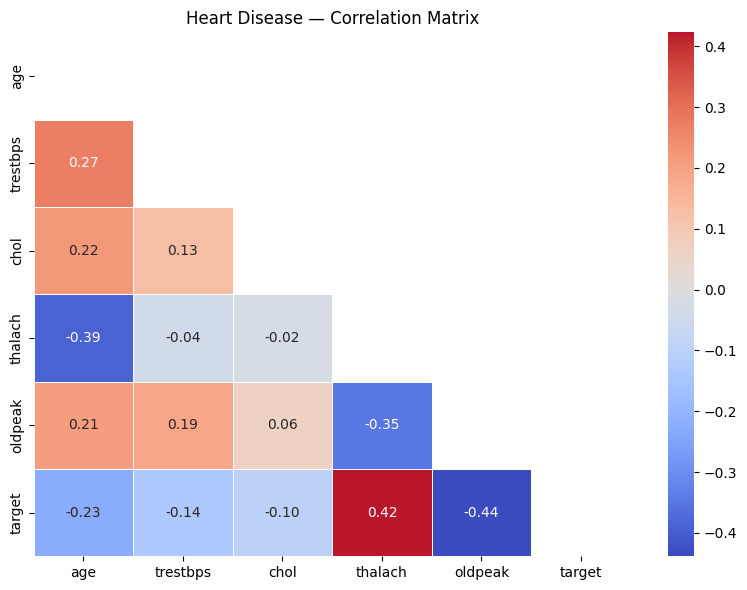

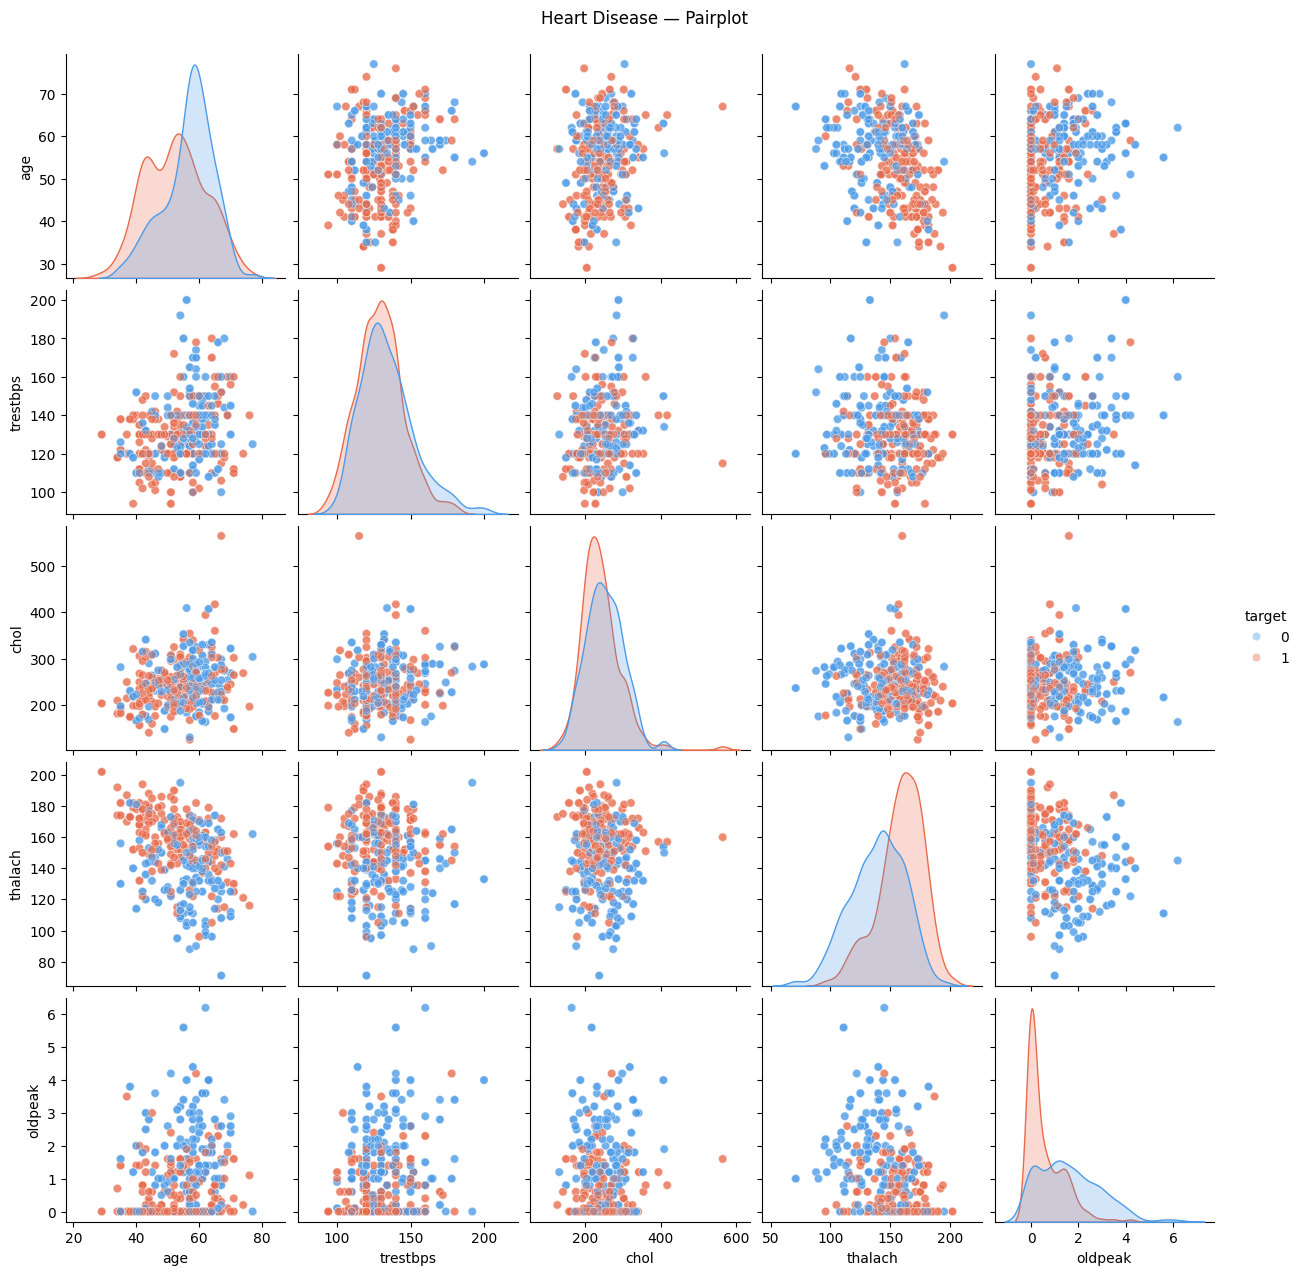


  DIABETES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.79947

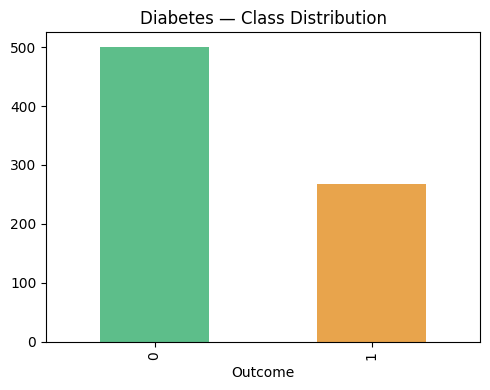

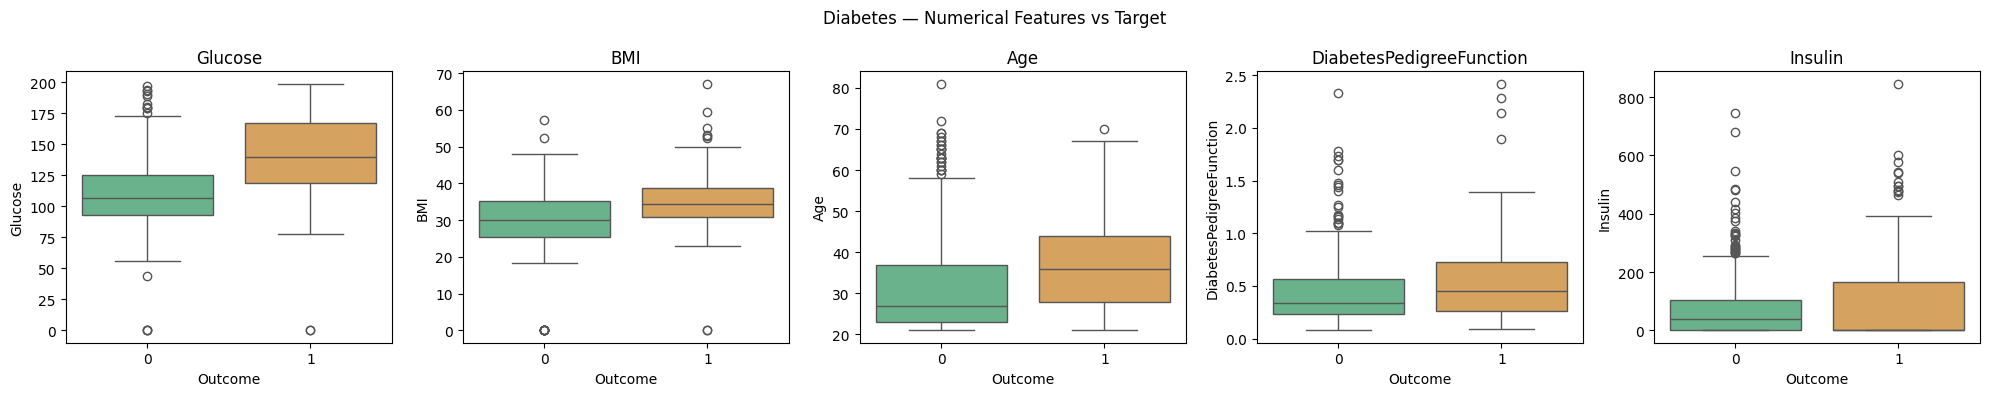

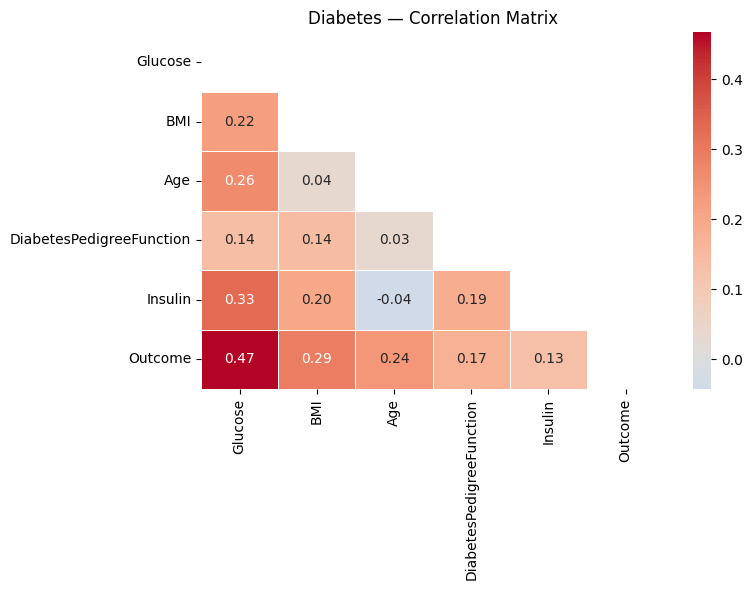

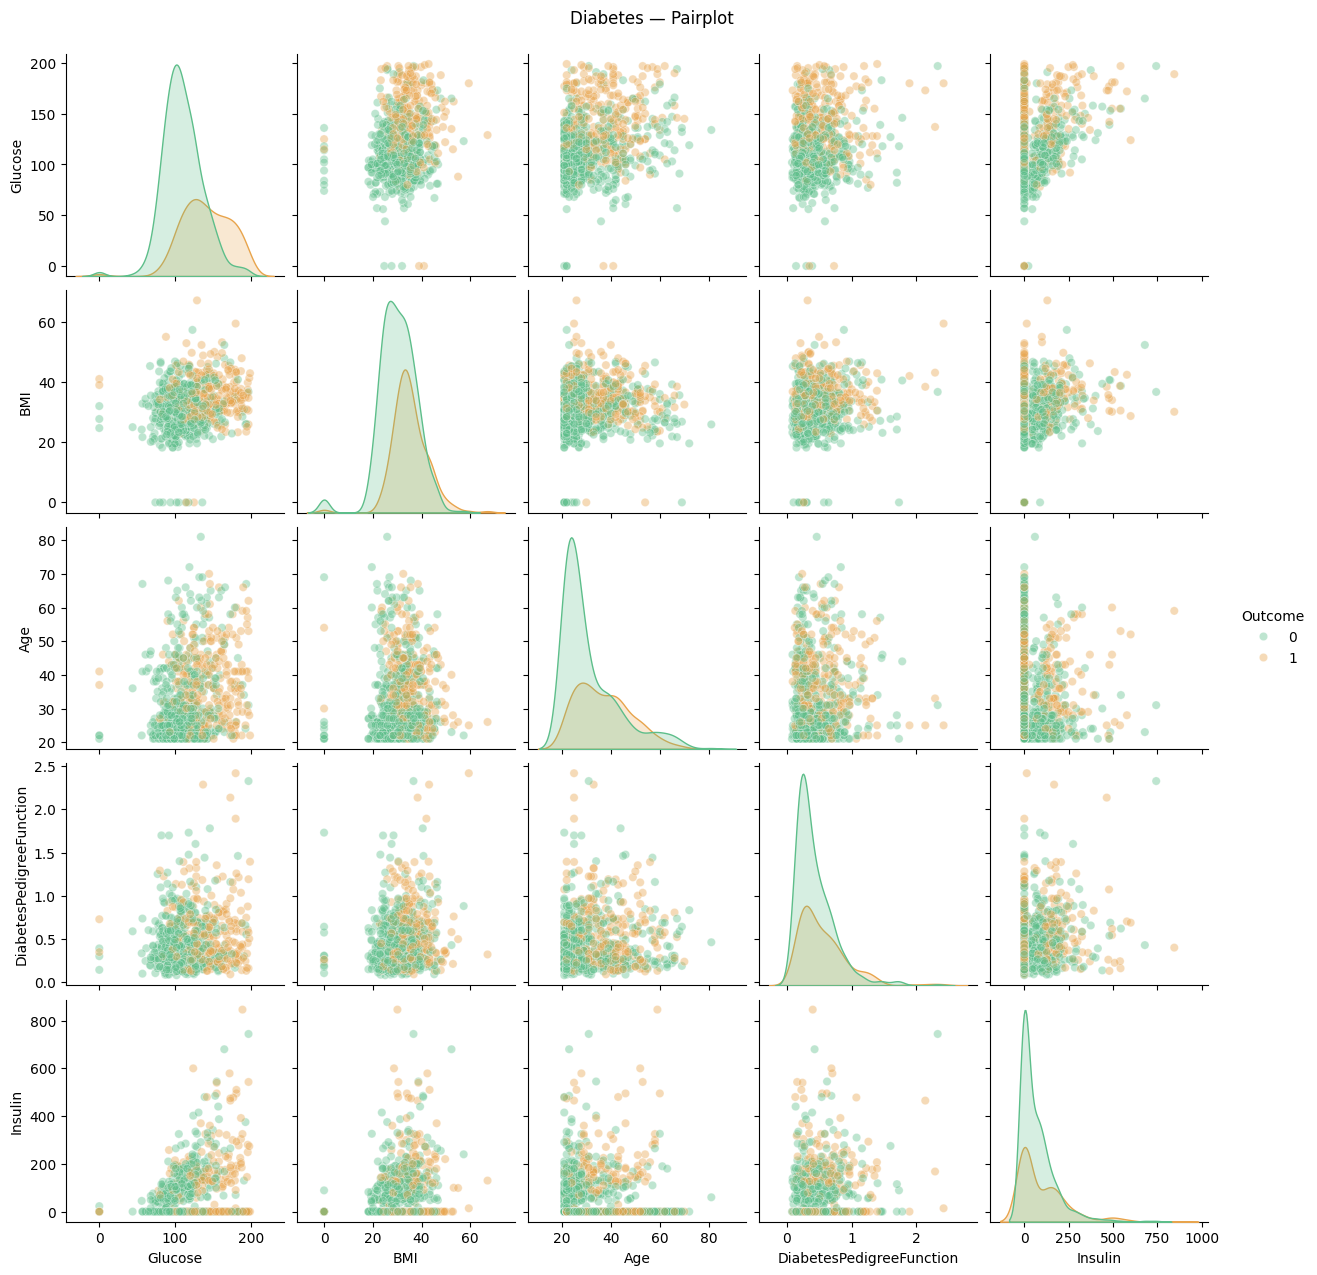


  BREAST CANCER
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se  

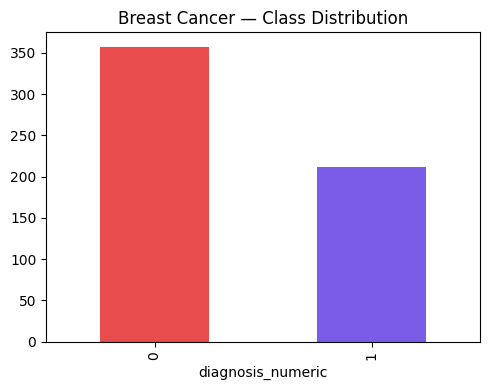

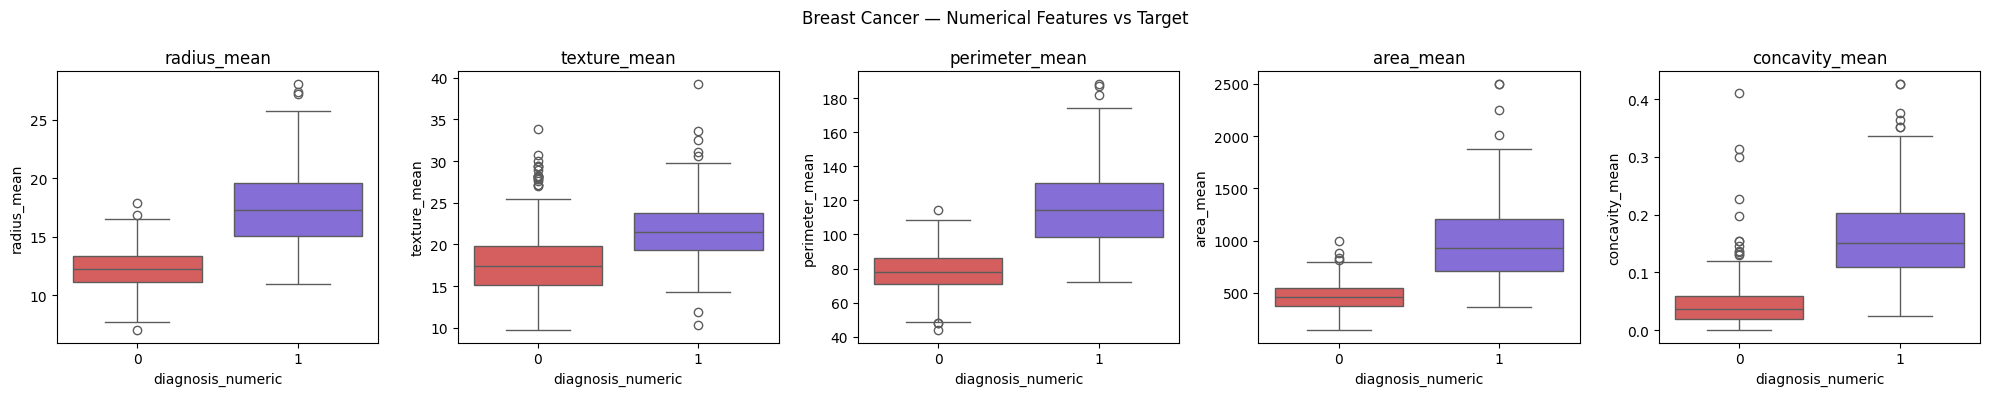

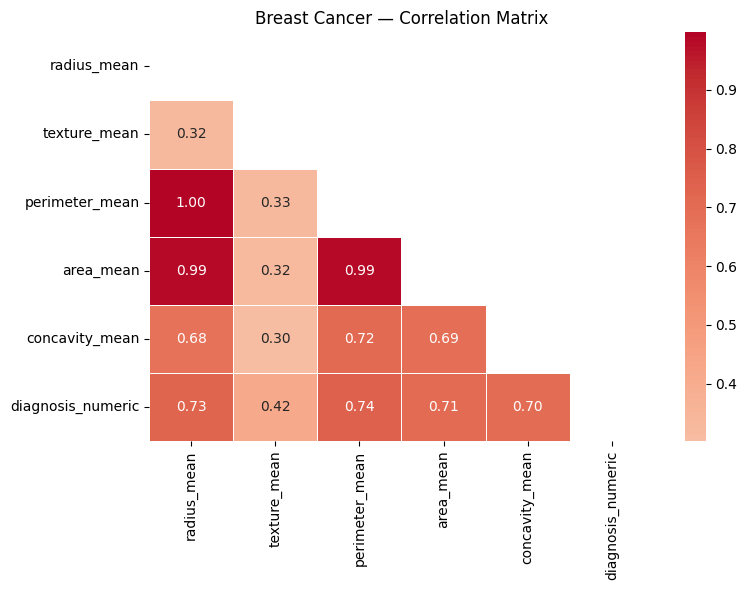

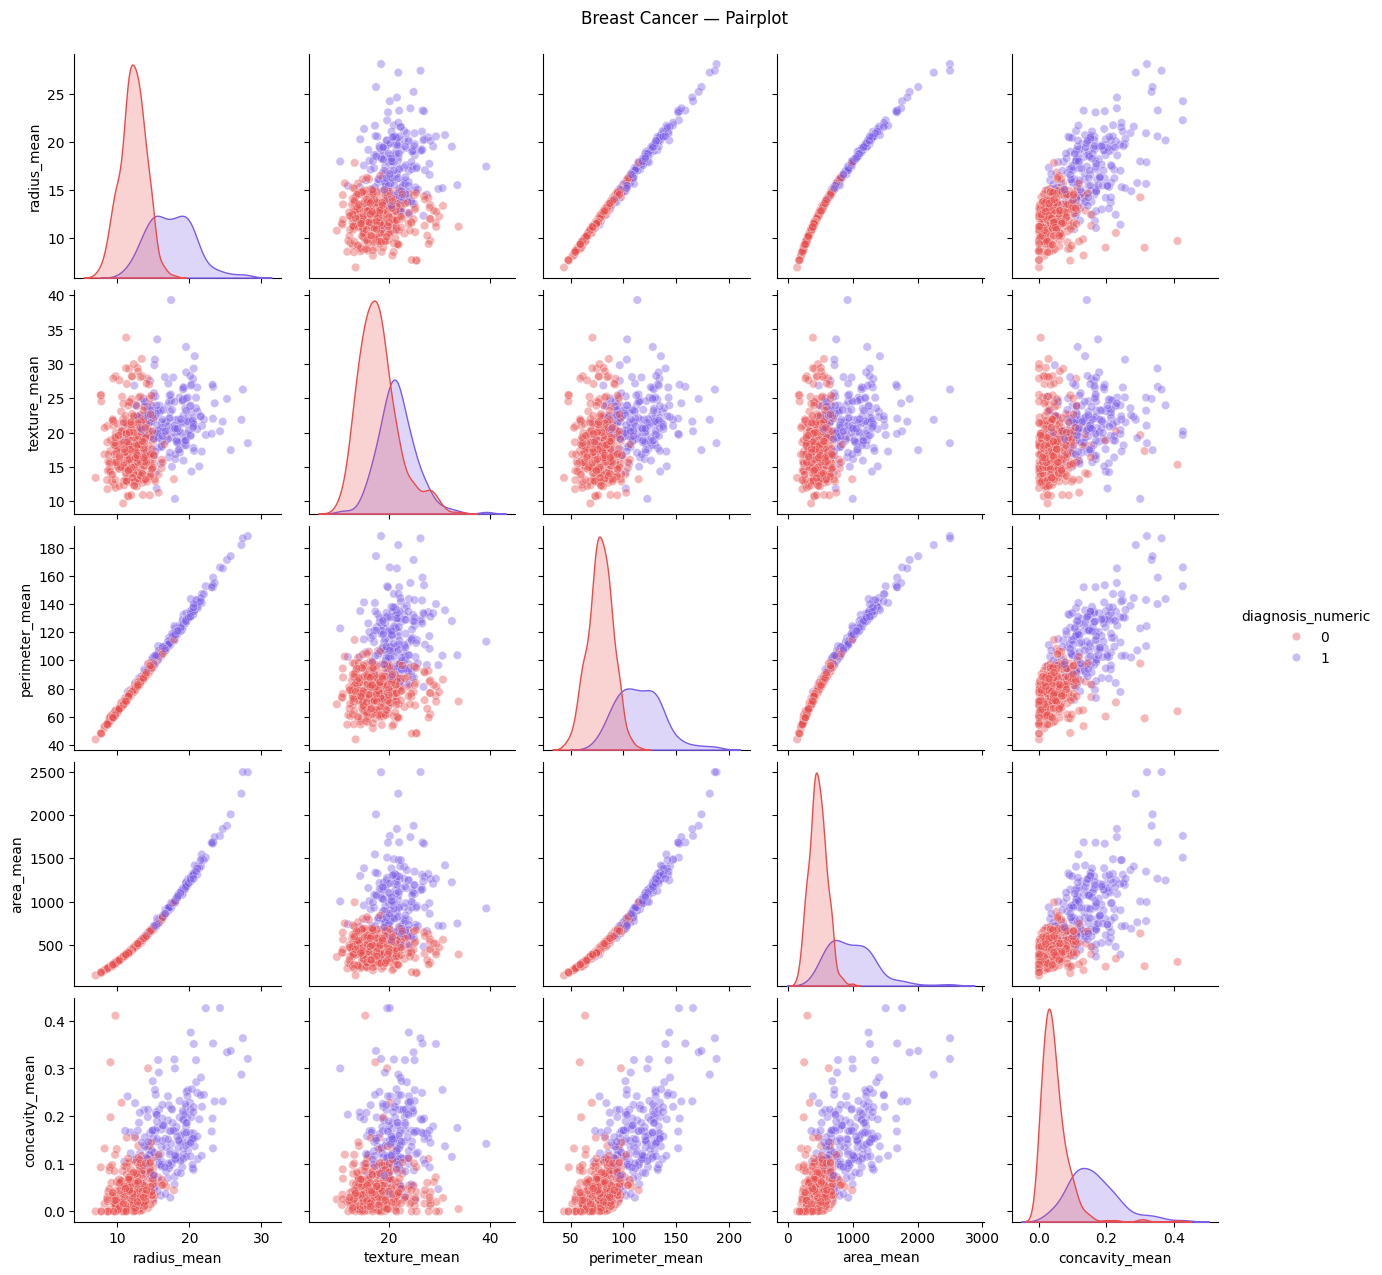

In [ ]:
def run_eda(df, target_col, dataset_name, num_cols, cat_cols=None, palette=None):
    """
    Runs complete EDA for a binary classification medical dataset.
    df          : DataFrame
    target_col  : name of the label column (str)
    dataset_name: display name (str)
    num_cols    : list of numerical feature column names
    cat_cols    : list of categorical feature column names (optional)
    palette     : list of 2 colors (optional)
    """
    if palette is None:
        palette = ['#4C9BE8', '#E86B4C']

    print(f"\n{'='*50}")
    print(f"  {dataset_name.upper()}")
    print(f"{'='*50}")
    print(df.info())
    print(df.describe())
    print(f"\nClass balance:\n{df[target_col].value_counts()}")
    print(f"\nMissing values:\n{df.isnull().sum()}")

    # Class distribution
    fig, ax = plt.subplots(figsize=(5, 4))
    df[target_col].value_counts().plot(kind='bar', ax=ax, color=palette)
    ax.set_title(f'{dataset_name} — Class Distribution')
    plt.tight_layout(); plt.show()

    # Boxplots
    n = len(num_cols)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, num_cols):
        sns.boxplot(data=df, x=target_col, y=col, hue=target_col, ax=ax, palette=palette, legend=False)
        ax.set_title(col)
    plt.suptitle(f'{dataset_name} — Numerical Features vs Target')
    plt.tight_layout(); plt.show()

    # Correlation heatmap
    plt.figure(figsize=(max(8, n), max(6, n-1)))
    corr = df[num_cols + [target_col]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', mask=mask,
                cmap='coolwarm', center=0, linewidths=0.5)
    plt.title(f'{dataset_name} — Correlation Matrix')
    plt.tight_layout(); plt.show()

    # Pairplot
    sns.pairplot(df[num_cols[:6] + [target_col]], hue=target_col,
                 palette=palette, plot_kws={'alpha':0.4}, diag_kind='kde')
    plt.suptitle(f'{dataset_name} — Pairplot', y=1.02); plt.show()


# ── Call for each dataset ───────────────────────────────────────────────────
run_eda(df_heart, 'target', 'Heart Disease',
        num_cols=['age','trestbps','chol','thalach','oldpeak'],
        cat_cols=['sex','cp','fbs'],
        palette=['#4C9BE8','#E86B4C'])

run_eda(df_diab, 'Outcome', 'Diabetes',
        num_cols=['Glucose','BMI','Age','DiabetesPedigreeFunction','Insulin'],
        palette=['#5DBE8A','#E8A44C'])

run_eda(df_bc_numeric.drop(columns=['target_name', 'diagnosis']), 'diagnosis_numeric', 'Breast Cancer',
        num_cols=['radius_mean','texture_mean','perimeter_mean',
                  'area_mean','concavity_mean'],
        palette=['#E84C4C','#7B5CE8'])

MODEL PIPELINE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              f1_score, accuracy_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
df_heart['ca']   = pd.to_numeric(df_heart['ca'],   errors='coerce')
df_heart['thal'] = pd.to_numeric(df_heart['thal'], errors='coerce')

X_heart = df_heart.drop(columns=['target'])
y_heart = df_heart['target']

# Impute → Scale
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp    = imputer.fit_transform(X_heart)
X_scaled = scaler.fit_transform(X_imp)

# Train/test split (stratified)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_scaled, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

# SMOTE on training set only
sm = SMOTE(random_state=42)
X_train_h, y_train_h = sm.fit_resample(X_train_h, y_train_h)

print(f"Heart Disease — Train: {X_train_h.shape}, Test: {X_test_h.shape}")
print(f"Class balance after SMOTE: {pd.Series(y_train_h).value_counts().to_dict()}")



Heart Disease — Train: (842, 13), Test: (205, 13)
Class balance after SMOTE: {0: 421, 1: 421}


In [ ]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_diab[zero_cols] = df_diab[zero_cols].replace(0, np.nan)

X_diab = df_diab.drop(columns=['Outcome'])
y_diab = df_diab['Outcome']

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp    = imputer.fit_transform(X_diab)
X_scaled = scaler.fit_transform(X_imp)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_scaled, y_diab, test_size=0.2, random_state=42, stratify=y_diab
)

sm = SMOTE(random_state=42)
X_train_d, y_train_d = sm.fit_resample(X_train_d, y_train_d)

print(f"Diabetes — Train: {X_train_d.shape}, Test: {X_test_d.shape}")
print(f"Class balance after SMOTE: {pd.Series(y_train_d).value_counts().to_dict()}")

Diabetes — Train: (800, 8), Test: (154, 8)
Class balance after SMOTE: {0: 400, 1: 400}


In [ ]:
X_bc = df_bc_numeric.drop(columns=['id', 'diagnosis', 'Unnamed: 32', 'target_name', 'diagnosis_numeric'])
y_bc = df_bc_numeric['diagnosis_numeric']

# No missing values in this dataset — go straight to scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bc)

# Feature selection — keep top 15 most informative features
selector  = SelectKBest(f_classif, k=15)
X_reduced = selector.fit_transform(X_scaled, y_bc)
selected_features = X_bc.columns[selector.get_support()].tolist()
print("Selected features:", selected_features)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_reduced, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

# Breast cancer is relatively balanced — SMOTE optional
print(f"Breast Cancer — Train: {X_train_b.shape}, Test: {X_test_b.shape}")
print(f"Class balance: {pd.Series(y_train_b).value_counts().to_dict()}")

Selected features: ['radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']
Breast Cancer — Train: (455, 15), Test: (114, 15)
Class balance: {0: 285, 1: 170}


In [ ]:
def train_all_models(X_train, y_train, dataset_name):
    """
    Trains SVM, Logistic Regression, Random Forest, XGBoost
    with GridSearchCV + StratifiedKFold. Returns dict of best estimators.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    model_grid = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, random_state=42),
            {"C": [0.01, 0.1, 1, 10, 100],
             "solver": ["lbfgs", "liblinear"]}
        ),
        "SVM": (
            SVC(probability=True, random_state=42),
            {"C": [0.1, 1, 10],
             "kernel": ["rbf", "linear"],
             "gamma": ["scale", "auto"]}
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=42),
            {"n_estimators": [100, 200],
             "max_depth": [None, 5, 10],
             "min_samples_split": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(eval_metric='logloss', random_state=42),
            {"n_estimators": [100, 200],
             "learning_rate": [0.05, 0.1, 0.2],
             "max_depth": [3, 5, 7],
             "subsample": [0.8, 1.0]}
        )
    }

    best_models = {}
    print(f"\n{'='*55}")
    print(f"  Training on: {dataset_name}")
    print(f"{'='*55}")

    for name, (model, params) in model_grid.items():
        gs = GridSearchCV(model, params, cv=cv, scoring='roc_auc',
                          n_jobs=-1, verbose=0)
        gs.fit(X_train, y_train)
        best_models[name] = gs.best_estimator_
        print(f"  {name:<22} Best ROC-AUC (CV): {gs.best_score_:.4f}  "
              f"| Params: {gs.best_params_}")

    return best_models

In [ ]:
def evaluate_all_models(models, X_test, y_test, dataset_name):
    """
    Prints classification report, plots confusion matrices
    and overlaid ROC curves for all models.
    """
    print(f"\n{'='*55}")
    print(f"  Results on TEST SET: {dataset_name}")
    print(f"{'='*55}")

    summary = []

    # ── Per-model metrics ───────────────────────────────────────────────────
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        acc   = accuracy_score(y_test, y_pred)
        f1    = f1_score(y_test, y_pred)
        auc   = roc_auc_score(y_test, y_prob)

        summary.append({"Model": name, "Accuracy": acc, "F1": f1, "ROC-AUC": auc})

        print(f"\n── {name} ──")
        print(classification_report(y_test, y_pred,
              target_names=['No Disease','Disease']))
        print(f"  ROC-AUC : {auc:.4f}")

        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=['No Disease','Disease'],
            ax=ax, colorbar=False, cmap='Blues'
        )
        ax.set_title(f"{name}\nAUC={auc:.3f}  F1={f1:.3f}", fontsize=10)

    plt.suptitle(f'{dataset_name} — Confusion Matrices', y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

    # ── Overlaid ROC curves ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = ['#4C9BE8','#E86B4C','#5DBE8A','#7B5CE8']
    for (name, model), color in zip(models.items(), colors):
        RocCurveDisplay.from_estimator(model, X_test, y_test,
                                       ax=ax, name=name, color=color)
    ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random (AUC=0.50)')
    ax.set_title(f'{dataset_name} — ROC Curve Comparison')
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()

    # ── Summary table ───────────────────────────────────────────────────────
    df_summary = pd.DataFrame(summary).set_index('Model').sort_values('ROC-AUC', ascending=False)
    df_summary = df_summary.applymap(lambda x: f"{x:.4f}")
    print(f"\n── Summary Table: {dataset_name} ──")
    print(df_summary.to_string())

    # ── Bar chart comparison ─────────────────────────────────────────────────
    df_plot = pd.DataFrame(summary).set_index('Model')
    df_plot.plot(kind='bar', figsize=(10, 5), color=['#4C9BE8','#5DBE8A','#E86B4C'])
    plt.title(f'{dataset_name} — Model Comparison')
    plt.ylabel('Score')
    plt.xticks(rotation=15, ha='right')
    plt.ylim(0.5, 1.0)
    plt.legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return df_summary


  Training on: Heart Disease
  Logistic Regression    Best ROC-AUC (CV): 0.9190  | Params: {'C': 0.1, 'solver': 'lbfgs'}
  SVM                    Best ROC-AUC (CV): 0.9867  | Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
  Random Forest          Best ROC-AUC (CV): 0.9984  | Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  XGBoost                Best ROC-AUC (CV): 0.9926  | Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

  Results on TEST SET: Heart Disease

── Logistic Regression ──
              precision    recall  f1-score   support

  No Disease       0.90      0.70      0.79       100
     Disease       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205

  ROC-AUC : 0.9286

── SVM ──
              precision    recall  f1-score   support

  No Disease       1.00     

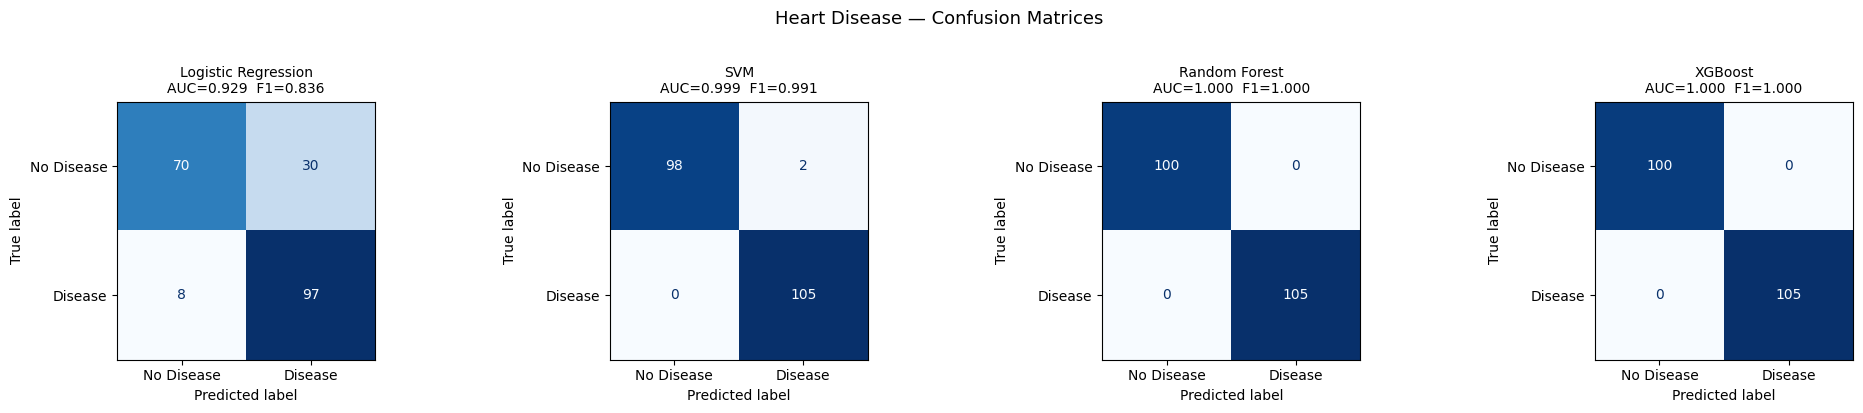

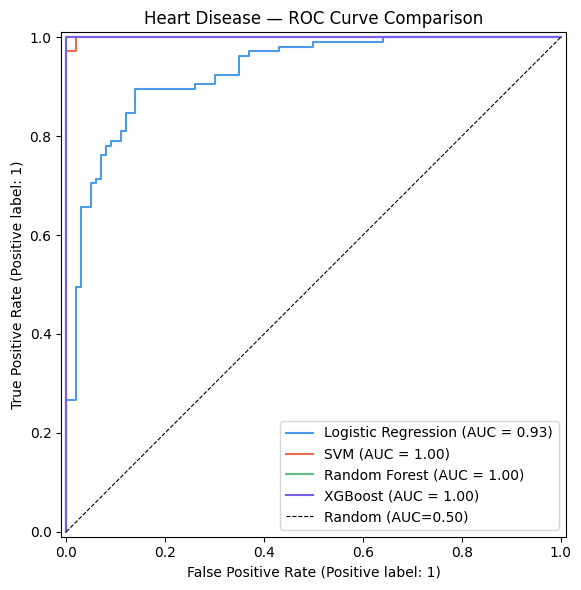


── Summary Table: Heart Disease ──
                    Accuracy      F1 ROC-AUC
Model                                       
XGBoost               1.0000  1.0000  1.0000
Random Forest         1.0000  1.0000  1.0000
SVM                   0.9902  0.9906  0.9994
Logistic Regression   0.8146  0.8362  0.9286


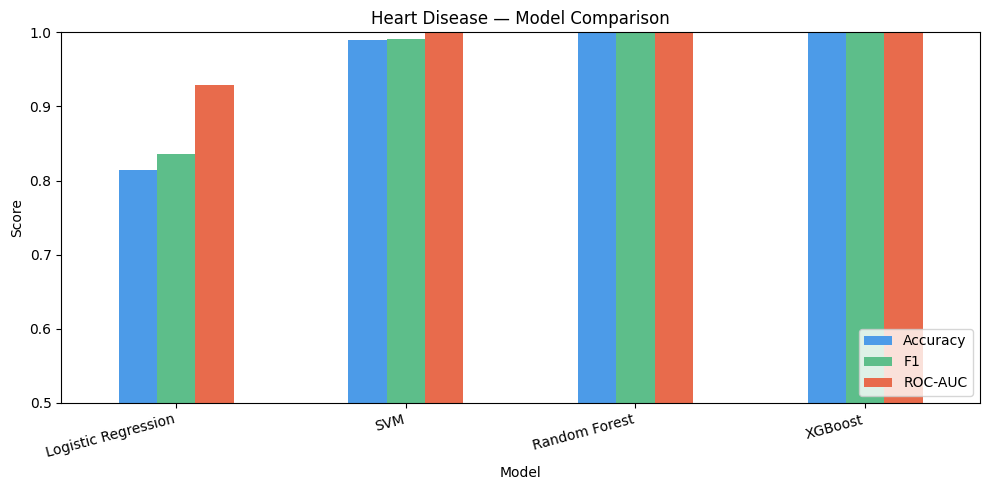


  Training on: Diabetes
  Logistic Regression    Best ROC-AUC (CV): 0.8410  | Params: {'C': 0.1, 'solver': 'liblinear'}
  SVM                    Best ROC-AUC (CV): 0.8779  | Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Random Forest          Best ROC-AUC (CV): 0.9025  | Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  XGBoost                Best ROC-AUC (CV): 0.8916  | Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

  Results on TEST SET: Diabetes

── Logistic Regression ──
              precision    recall  f1-score   support

  No Disease       0.80      0.74      0.77       100
     Disease       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154

  ROC-AUC : 0.8081

── SVM ──
              precision    recall  f1-score   support

  No Disease       0.78      0.72

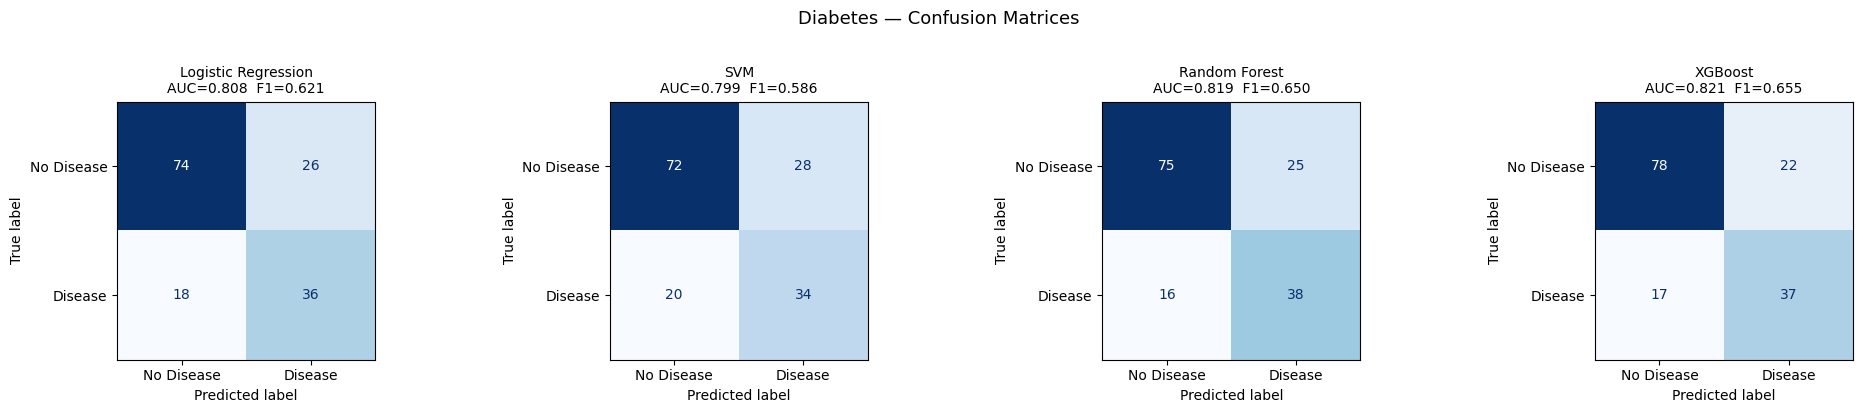

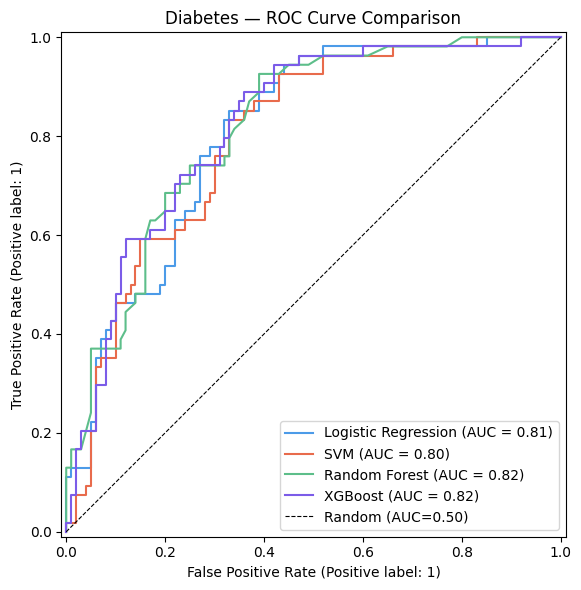


── Summary Table: Diabetes ──
                    Accuracy      F1 ROC-AUC
Model                                       
XGBoost               0.7468  0.6549  0.8213
Random Forest         0.7338  0.6496  0.8187
Logistic Regression   0.7143  0.6207  0.8081
SVM                   0.6883  0.5862  0.7989


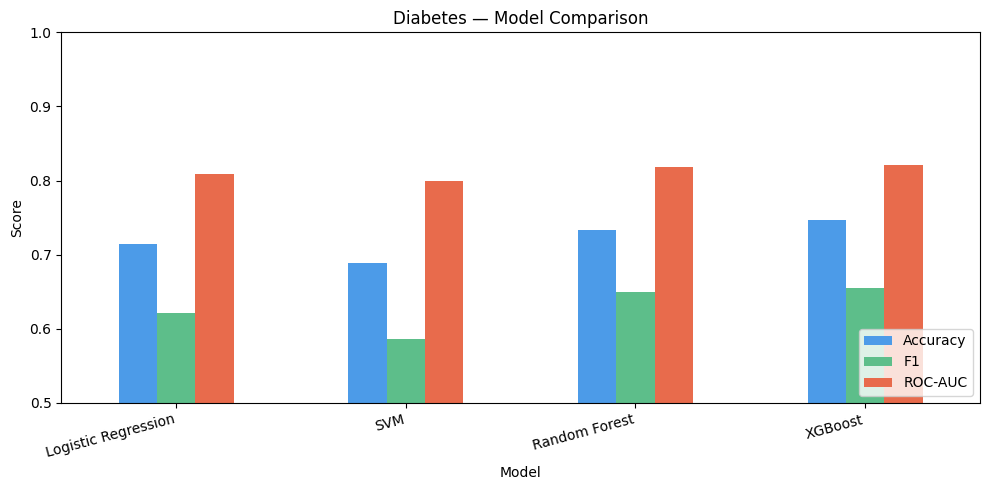


  Training on: Breast Cancer
  Logistic Regression    Best ROC-AUC (CV): 0.9898  | Params: {'C': 100, 'solver': 'lbfgs'}
  SVM                    Best ROC-AUC (CV): 0.9894  | Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
  Random Forest          Best ROC-AUC (CV): 0.9868  | Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  XGBoost                Best ROC-AUC (CV): 0.9878  | Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

  Results on TEST SET: Breast Cancer

── Logistic Regression ──
              precision    recall  f1-score   support

  No Disease       0.96      0.99      0.97        72
     Disease       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  ROC-AUC : 0.9990

── SVM ──
              precision    recall  f1-score   support

  No Disease       0.95     

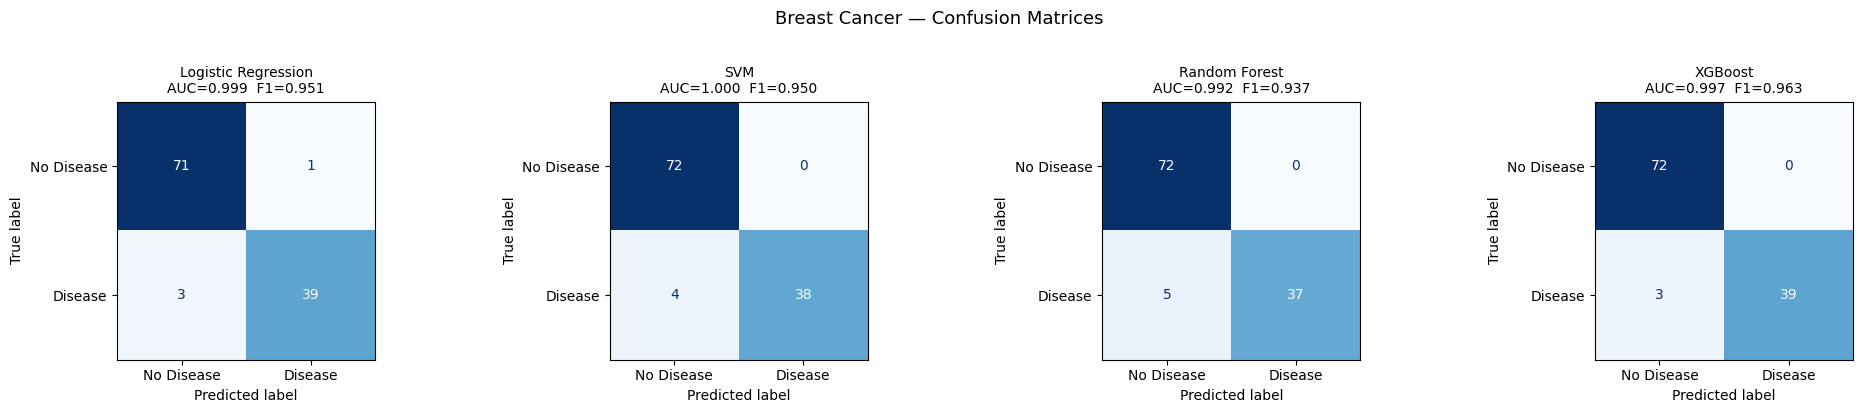

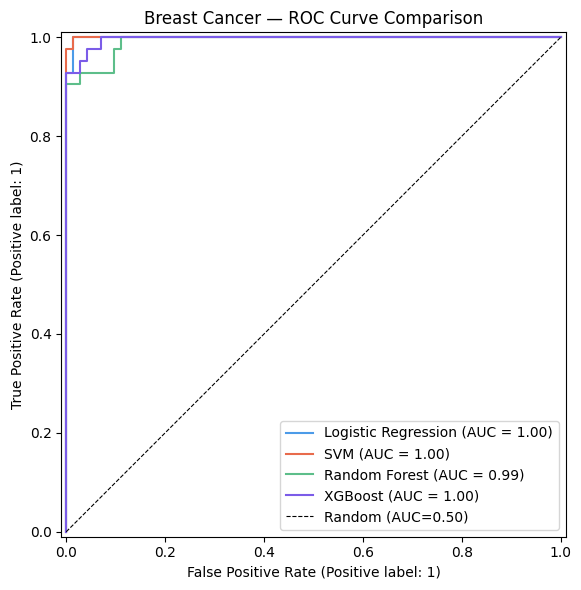


── Summary Table: Breast Cancer ──
                    Accuracy      F1 ROC-AUC
Model                                       
SVM                   0.9649  0.9500  0.9997
Logistic Regression   0.9649  0.9512  0.9990
XGBoost               0.9737  0.9630  0.9967
Random Forest         0.9561  0.9367  0.9921


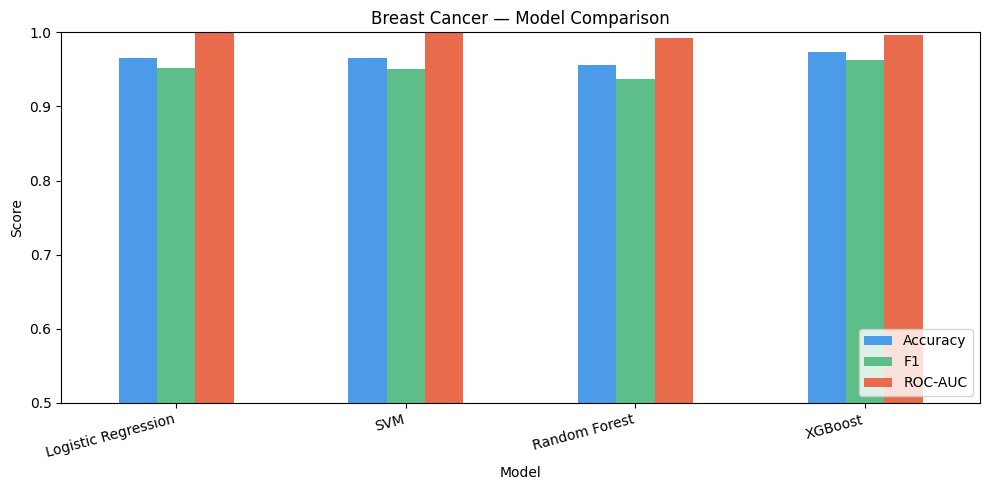

In [ ]:
# ── Heart Disease ─────────────────────────────────────────────────────────────
models_heart  = train_all_models(X_train_h, y_train_h, "Heart Disease")
results_heart = evaluate_all_models(models_heart, X_test_h, y_test_h, "Heart Disease")

# ── Diabetes ──────────────────────────────────────────────────────────────────
models_diab  = train_all_models(X_train_d, y_train_d, "Diabetes")
results_diab = evaluate_all_models(models_diab, X_test_d, y_test_d, "Diabetes")

# ── Breast Cancer ─────────────────────────────────────────────────────────────
models_bc  = train_all_models(X_train_b, y_train_b, "Breast Cancer")
results_bc = evaluate_all_models(models_bc, X_test_b, y_test_b, "Breast Cancer")